# Music Recommender — End-to-End Pipeline
Complete pipeline: dataset extraction → user data → jSymbolic features → KG construction & enrichment → baselines → autoencoder → HGT recommender.  
Every major section checks for cached artefacts on disk before re-running expensive steps. Set `FORCE_REBUILD = True` to invalidate all caches.

## Environment Setup (Colab vs. Local)

This cell detects whether the notebook is running on **Google Colab** or **locally** and sets up the environment accordingly.

### How the two environments work

| | Local (VSCode) | Google Colab |
|---|---|---|
| **Code** (`src/`) | This repo, on disk | Cloned fresh from GitHub |
| **Data** (`data/`) | `<repo>/data/` | Mounted from Google Drive |
| **Model weights** | `<repo>/models/` | Downloaded from W&B artifacts |
| **jSymbolic** | `<repo>/jSymbolic/` | Copied from Google Drive |
| **API keys** | `.env` file (gitignored) | Colab Secrets (🔑 sidebar) |

### One-time Google Drive setup (Colab only)
Upload your `data/` folder to Google Drive under a folder called `DL-KG-project/`
so the layout is: `MyDrive/DL-KG-project/data/raw/`, `…/data/processed/`, etc.
Also copy `jSymbolic/` there: `MyDrive/DL-KG-project/jSymbolic/`.

### W&B on Colab
Add your W&B API key as a **Colab Secret** named `WANDB_API_KEY`
(🔑 icon in the left sidebar → "Add new secret").

In [2]:
"""
Environment bootstrap — run this cell first.
Detects Colab vs. local and prepares ROOT, installs deps, mounts Drive.
"""
import sys, os
from pathlib import Path

# ── 0.1  Detect runtime ───────────────────────────────────────────────────────
try:
    import google.colab          # only importable inside Colab
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

print(f"Runtime: {'Google Colab' if ON_COLAB else 'Local (VSCode / Jupyter)'}")

# ── 0.2  Colab branch ─────────────────────────────────────────────────────────
if ON_COLAB:
    import subprocess
    from google.colab import drive, userdata

    # 0.2a  Mount Google Drive (prompts for auth on first run)
    drive.mount("/content/drive")

    # 0.2b  Clone / update the repo from GitHub so src/ is available
    REPO_URL  = "https://github.com/aarthip97/DL-KG-project.git"
    REPO_DIR  = Path("/content/DL-KG-project")
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
        print(f"Cloned repo → {REPO_DIR}")
    else:
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)
        print(f"Repo already present, pulled latest → {REPO_DIR}")

    ROOT = REPO_DIR

    # 0.2c  Install Python dependencies
    subprocess.run(
        ["pip", "install", "-q", "-r", str(ROOT / "requirements.txt")],
        check=True,
    )
    print("Requirements installed.")

    # 0.2d  Point to data in Google Drive
    #   Set gdrive_proj_path in Colab Secrets (🔑 sidebar) OR accept the default.
    #   Expected Drive layout:
    #     MyDrive/DL-KG-project/data/raw/
    #     MyDrive/DL-KG-project/data/processed/
    #     MyDrive/DL-KG-project/jSymbolic/jSymbolic2.jar
    try:
        _gdrive_proj = Path(userdata.get("gdrive_proj_path"))
    except Exception:
        _gdrive_proj = Path("/content/drive/MyDrive/DL-KG-project")
        print(f"  [INFO] gdrive_proj_path not set in Secrets; defaulting to {_gdrive_proj}")

    GDRIVE_DATA_ROOT = _gdrive_proj / "data"
    JSYMBOLIC_JAR    = _gdrive_proj / "jSymbolic" / "jSymbolic2.jar"

    # 0.2e  Authenticate W&B via Colab Secret (add key named WANDB_API_KEY in 🔑 sidebar)
    try:
        import wandb
        wandb.login(key=userdata.get("WANDB_API_KEY"), relogin=True)
        print("W&B authenticated via Colab Secret.")
    except Exception as e:
        print(f"  [WARN] W&B login skipped: {e}")

# ── 0.3  Local branch ─────────────────────────────────────────────────────────
else:
    # Load .env for local secrets (jSymbolic path, gdrive path if needed)
    try:
        from dotenv import load_dotenv
        load_dotenv(dotenv_path=Path(__file__).parents[1] / ".env"
                    if "__file__" in dir() else Path.cwd().parent / ".env")
    except ImportError:
        pass  # dotenv optional locally

    ROOT             = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
    GDRIVE_DATA_ROOT = None   # not used locally; data lives in ROOT/data/
    JSYMBOLIC_JAR    = Path(os.getenv("jSymbolic2_path",
                            str(ROOT / "jSymbolic" / "jSymbolic2.jar")))

# ── 0.4  Add src/ to Python path (works for both environments) ────────────────
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

print(f"ROOT             : {ROOT.relative_to(ROOT.parent)}")
print(f"GDRIVE_DATA_ROOT : {GDRIVE_DATA_ROOT.relative_to(ROOT.parent) if GDRIVE_DATA_ROOT else None}")
print(f"jSymbolic jar    : {JSYMBOLIC_JAR.relative_to(ROOT)}  ({'found' if JSYMBOLIC_JAR.exists() else 'NOT FOUND'})")

Runtime: Local (VSCode / Jupyter)
ROOT             : DL-KG-project
GDRIVE_DATA_ROOT : None
jSymbolic jar    : jSymbolic/jSymbolic2.jar  (found)


In [3]:
from __future__ import annotations
import warnings, re, json, subprocess, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import importlib
import gc
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# ROOT, ON_COLAB, GDRIVE_DATA_ROOT, JSYMBOLIC_JAR and sys.path are set by the
# environment-setup cell above.  We just reference them here.

# ── Data root (differs between local and Colab) ────────────────────────────────
# On Colab  → data lives in Google Drive (GDRIVE_DATA_ROOT set above)
# Locally   → data lives next to this repo (ROOT/data/)
_DATA = GDRIVE_DATA_ROOT if ON_COLAB else ROOT / "data"

# ── Data paths ─────────────────────────────────────────────────────────────────
RAW            = _DATA / "raw"
INTERIM        = _DATA / "interim"
PROCESSED      = _DATA / "processed"
FINAL          = _DATA / "final"
ONTOLOGY       = _DATA / "ontology"

# Evaluation / result artifacts — lightweight CSVs, plots, qualitative outputs
FINAL_MODELS_DIR = FINAL / "models"
KNN_RESULTS_DIR  = FINAL_MODELS_DIR / "knn"
HGT_RESULTS_DIR  = FINAL_MODELS_DIR / "hgt"
AE_RESULTS_DIR   = FINAL_MODELS_DIR / "autoencoder"

# Model weights / checkpoints — live in ROOT/models/ (gitignored via models/*)
# On Colab, ROOT is the cloned repo at /content/DL-KG-project, so weights are
# written there during the session; persist them via W&B artifacts.
MODELS_DIR     = ROOT / "models"
AE_WEIGHTS_DIR = MODELS_DIR / "autoencoder"
HGT_WEIGHTS_DIR= MODELS_DIR / "hgt"
KNN_CACHE_DIR  = MODELS_DIR / "knn"

for p in [INTERIM, PROCESSED, FINAL,
          KNN_RESULTS_DIR, HGT_RESULTS_DIR, AE_RESULTS_DIR,
          AE_WEIGHTS_DIR, HGT_WEIGHTS_DIR, KNN_CACHE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ── Artefact paths ─────────────────────────────────────────────────────────────
# Raw / interim data
LAKH_PQ            = PROCESSED / "lakh_msd_dataset.parquet"
TASTE_PQ           = PROCESSED / "taste_profile_filtered.parquet"
PER_USER_CSV       = PROCESSED / "taste_profile_per_user.csv"
PER_SONG_CSV       = PROCESSED / "taste_profile_per_song.csv"
INTERIM_CSV        = INTERIM   / "interim.csv"
KG_INPUT_PQ        = INTERIM   / "kg_input.parquet"
KG_TASTE_PQ        = INTERIM   / "kg_taste_profile.parquet"

# Ontology / KG outputs
ONTO_BASE          = ONTOLOGY  / "MusicRecSyst.ttl"
ONTO_OUT           = FINAL     / "MusicRecSyst_populated.ttl"
ONTO_OUT_SIMPLE    = FINAL     / "MusicRecSyst_populated_simple.ttl"
LISTENING_NT       = FINAL     / "MusicRecSyst_listening.nt"
LISTENING_NT_SIM   = FINAL     / "MusicRecSyst_listening_simple.nt"

# Autoencoder — weights in models/, embeddings (intermediate data) in interim/
AE_EMBEDDINGS_PQ   = INTERIM       / "ae_embeddings.parquet"
AE_MODEL_PATH      = AE_WEIGHTS_DIR / "ae_model.pt"

# KNN — neighbour cache (binary, large) in models/knn/; metrics in data/final/models/knn/
KNN_VAL_CSV        = KNN_RESULTS_DIR / "knn_cf_val_sweep_results.csv"
KNN_TEST_CSV       = KNN_RESULTS_DIR / "knn_cf_final_test_summary.csv"
KNN_NBRS_CACHE     = KNN_CACHE_DIR   / "knn_cf_val_sweep_results_nbrs.npz"
KNN_POP_CSV        = KNN_RESULTS_DIR / "knn_pop_metrics.csv"
KNN_POP_JSON       = KNN_RESULTS_DIR / "knn_pop_metrics.json"
KNN_VAL_PLOT_PNG   = KNN_RESULTS_DIR / "knn_val_sweep.png"
KFOLD_CSV          = KNN_RESULTS_DIR / "knn_cf_kfold_results.csv"
SPLIT_PQ           = PROCESSED       / "train_val_test_splits.parquet"
FINAL_SPLITS_DIR   = KNN_RESULTS_DIR

# HGT — weights + pickled result in models/hgt/; metrics/plots in data/final/models/hgt/
HGT_MODEL_PATH     = HGT_WEIGHTS_DIR / "hgt_model.pt"
HGT_RESULT_PATH    = HGT_WEIGHTS_DIR / "hgt_results.pkl"

# ── Global flags ───────────────────────────────────────────────────────────────
FORCE_REBUILD    = False   # set True to invalidate all file-based caches
FORCE_REBUILD_WD = False   # set True to re-query Wikidata (slow)
RUN_WIKIDATA     = True    # set False to skip Wikidata enrichment entirely
SKIP_DOWNLOAD    = True    # set False to re-download raw data from the internet
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"

# ── W&B (Weights & Biases) — global project config ────────────────────────────
WANDB_PROJECT = "music-recommender-system"
WANDB_ENTITY  = None       # set to your W&B username/team, or leave None
WANDB_GROUP   = "KG-DL-PROJECT"  # groups all runs of this experiment family

print("ROOT              :", ROOT.relative_to(ROOT.parent))
print("data root         :", _DATA.relative_to(ROOT))
print("device            :", DEVICE)
print("FORCE_REBUILD     :", FORCE_REBUILD)
print(f"W&B project       : {WANDB_PROJECT}  (group={WANDB_GROUP})")
print("\nKey output directories:")
print(f"  model weights   → {MODELS_DIR.relative_to(ROOT)}/")
print(f"  evaluation artifacts  → {FINAL_MODELS_DIR.relative_to(ROOT)}/")

# Force-reload any already-imported src/ modules so changes take effect
# without a kernel restart — just re-run this cell.
_src_prefix = str(ROOT / "src")
for _mod_name, _mod in list(sys.modules.items()):
    _mod_file = getattr(_mod, "__file__", None) or ""
    if _src_prefix in _mod_file:
        try:
            importlib.reload(_mod)
        except Exception as _e:
            pass
print("\nSource modules reloaded.")

ROOT              : DL-KG-project
data root         : data
device            : cpu
FORCE_REBUILD     : False
W&B project       : music-recommender-system  (group=KG-DL-PROJECT)

Key output directories:
  model weights   → models/
  evaluation artifacts  → data/final/models/

Source modules reloaded.


## 1 — Lakh MIDI and Million Song Dataset Extraction
Links Lakh MIDI files to Million Song Dataset tracks, keeps matches with DTW score ≥ 0.55, reads MSD HDF5 metadata, extracts MIDI instrumentation and other useful fields, deduplicates records, and saves the result to `data/processed/lakh_msd_dataset.parquet`.

>**Note**: the HDF5 metadata/songs genre field was empty in this dump and many analysis arrays are multidimensional/unused, so those were omitted. Several attributes are derived directly from the MIDI files instead of from those HDF5 arrays.

In [4]:
import h5py
from pathlib import Path

H5_ROOT = Path('../data/raw/lmd_matched_h5')
# Safely get the first .h5 file (returns None if no match)
sample = next(H5_ROOT.rglob('*.h5'), None)

if sample is None:
    raise FileNotFoundError(f"No .h5 files found under {H5_ROOT!s}. "
                            "Ensure the data are downloaded and the path is correct.")

def print_h5_structure(name, obj):
    indent = "  " * name.count("/")
    if isinstance(obj, h5py.Dataset):
        print(f"{indent} {name}  \n    shape={obj.shape}  dtype={obj.dtype}")
        # Print first value for compound/string datasets
        if getattr(obj, "shape", None) and getattr(obj.dtype, "names", None):
            list_fields = list(obj.dtype.names)
            if len(list_fields) > 5:
                lines = [list_fields[i:i+5] for i in range(0, len(list_fields), 5)]
                for line in lines:
                    print(f"{indent}   fields: {line}")
            else:
                print(f"{indent}   fields: {list_fields}")
    else:
        print(f"{indent} {name}/")

print(f"File: {sample}\n")
with h5py.File(sample, 'r') as f:
    f.visititems(print_h5_structure)

File: ../data/raw/lmd_matched_h5/L/L/S/TRLLSTQ128F1490A26.h5

 analysis/
   analysis/bars_confidence  
    shape=(73,)  dtype=float64
   analysis/bars_start  
    shape=(73,)  dtype=float64
   analysis/beats_confidence  
    shape=(296,)  dtype=float64
   analysis/beats_start  
    shape=(296,)  dtype=float64
   analysis/sections_confidence  
    shape=(10,)  dtype=float64
   analysis/sections_start  
    shape=(10,)  dtype=float64
   analysis/segments_confidence  
    shape=(432,)  dtype=float64
   analysis/segments_loudness_max  
    shape=(432,)  dtype=float64
   analysis/segments_loudness_max_time  
    shape=(432,)  dtype=float64
   analysis/segments_loudness_start  
    shape=(432,)  dtype=float64
   analysis/segments_pitches  
    shape=(432, 12)  dtype=float64
   analysis/segments_start  
    shape=(432,)  dtype=float64
   analysis/segments_timbre  
    shape=(432, 12)  dtype=float64
   analysis/songs  
    shape=(1,)  dtype=[('analysis_sample_rate', '<i4'), ('audio_md5', 'S32'

In [5]:
from data.dataset_extraction import LakhMSDLinker, load_dataset

# ── 1.1 Download raw data (run once) ─────────────────────────────────────────
if not SKIP_DOWNLOAD:
    subprocess.run([sys.executable, str(ROOT / "scripts" / "download_lmd.py"),
                    "--dest", str(RAW), "--skip-existing"], check=True)

# ── 1.2 Auto-detect paths from manifest ──────────────────────────────────────
_manifest = json.loads((RAW / "manifest.json").read_text()) if (RAW / "manifest.json").exists() else {}
MIDI_ROOT         = Path(_manifest.get("lmd_matched",    {}).get("unpacked", RAW / "lmd_matched"))
H5_ROOT           = Path(_manifest.get("lmd_matched_h5", {}).get("unpacked", RAW / "lmd_matched_h5"))
MATCH_SCORES_PATH = Path(_manifest.get("match_scores",   {}).get("archive",  RAW / "match_scores.json"))

for label, p in [("MIDI root", MIDI_ROOT), ("HDF5 root", H5_ROOT), ("match_scores", MATCH_SCORES_PATH)]:
    print(f"  {'✓' if p.exists() else '✗'}  {label}: {p.relative_to(ROOT)}")

# ── 1.3 Build or load dataset ────────────────────────────────────────────────
if LAKH_PQ.exists() and not FORCE_REBUILD:
    lakh_df = load_dataset(LAKH_PQ)
    print(f"[SKIP] loaded lakh_msd from {LAKH_PQ.relative_to(ROOT)}  shape={lakh_df.shape}")
else:
    linker = LakhMSDLinker(midi_root=MIDI_ROOT, h5_root=H5_ROOT,
                           match_scores_path=MATCH_SCORES_PATH,
                           min_score=0.55, pick_midi="best")
    lakh_df = linker.build_dataset(max_tracks=None, verbose=True, include_midi=True)
    lakh_df.to_parquet(LAKH_PQ, index=False)
    lakh_df[[ c for c in lakh_df.columns
              if not isinstance(lakh_df[c].iloc[0] if len(lakh_df) else None, list)
            ]].to_csv(LAKH_PQ.with_suffix(".csv"), index=False)
    print(f"saved → {LAKH_PQ.relative_to(ROOT)}  shape={lakh_df.shape}")

print(f"\nDataset: {len(lakh_df):,} tracks, {lakh_df.shape[1]} columns")
display(lakh_df.head())

  ✓  MIDI root: data/raw/lmd_matched
  ✓  HDF5 root: data/raw/lmd_matched_h5
  ✓  match_scores: data/raw/match_scores.json
[SKIP] loaded lakh_msd from data/processed/lakh_msd_dataset.parquet  shape=(19037, 40)

Dataset: 19,037 tracks, 40 columns
[SKIP] loaded lakh_msd from data/processed/lakh_msd_dataset.parquet  shape=(19037, 40)

Dataset: 19,037 tracks, 40 columns


,track_id,midi_path,match_score,song_id,artist_id,artist_mbid,audio_md5,artist_name,title,release,artist_location,artist_latitude,artist_longitude,artist_familiarity,artist_hotttnesss,song_hotttnesss,key,key_name,key_confidence,mode,mode_name,mode_confidence,tempo,time_signature,time_signature_confidence,duration,loudness,danceability,energy,year,artist_terms,artist_terms_freq,artist_terms_weight,primary_genre,top3_genres,similar_artists,artist_mbtags,artist_mbtags_count,midi_n_instruments,midi_instrument_names
0,TRAAAGR128F425B14B,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.742663,SONRWUU12AF72A4283,ARGE7G11187FB37E05,7bd9e20e-74b9-446a-a2ed-a223f82a36e7,7573fabe891b25bcd3c5866e4c5df1f0,Cyndi Lauper,Into The Nightlife,Bring Ya To The Brink,"Brooklyn, NY",NaN,NaN,0.712886,0.559257,NaN,9,A,0.608,0,minor,0.495,123.989,4,0.800,240.63955,-7.322,0.0,0.0,2008.0,"[new wave, rock, pop, ballad, soundtrack]","[1.0, 0.9496095498321674, 0.9209438924950107, ...","[1.0, 0.8274088968810257, 0.8362373810229121, ...",new wave,"[new wave, rock, pop]","[ARPMB2A1187FB4D306, ARDGYV01187B9BA3DD, ARNCX...",[classic pop and rock],[1],16.0,"[Shamisen, Electric Guitar (muted), Pan Flute,..."
1,TRAAAZF12903CCCF6B,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.665684,SOUCVHW12AB018E830,ARJJ8611187FB5321F,471e21ab-7a14-4190-a9d2-f95197616df4,facaf1c26c48d98e6b20c54b4d02051b,Matthew Wilder,Break My Stride,I Don't Speak The Language,"New York, NY [Manhattan]",40.79086,-73.96644,0.546102,0.383787,NaN,10,A#,0.456,1,major,0.442,110.129,4,0.711,184.47628,-11.137,0.0,0.0,1983.0,"[rock, pop rock, electronic, disco, pop]","[1.0, 0.9991508807119213, 0.9825076366910069, ...","[0.8669636173576897, 1.0, 0.8666714916235556, ...",rock,"[rock, pop rock, electronic]","[ARWSN471187B9A6F7F, ARU7CW61187FB51117, AR74P...",None,None,6.0,"[Pad 3 (polysynth), Electric Bass (finger), El..."
2,TRAABVM128F92CA9DC,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.731250,SOXLBJT12A8C140925,ARYKCQI1187FB3B18F,eeacb319-8d4c-48e0-80a0-944e71c375bf,3e57f1f9670a3aa3bd8901e6eee32149,Tesla,Caught In A Dream,Gold,NaN,NaN,NaN,0.707200,0.513463,0.684136,7,G,0.725,1,major,0.756,150.062,4,0.931,290.29832,-5.271,0.0,0.0,2004.0,"[hard rock, rock, heavy metal, classic rock, b...","[1.0, 0.9731986233060094, 0.9573587331618035, ...","[1.0, 0.8962468895285768, 0.9755238307281503, ...",hard rock,"[hard rock, rock, heavy metal]","[ARO353H1187B9A43E9, ARV8LAR1187FB3DE2A, AREGV...",None,None,15.0,"[Electric Bass (finger), Lead 1 (square), Shak..."
3,TRAABXH128F42955D6,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.747489,SOHXFBA12A8C13D637,ARD9UVF1187B9B17FE,634fe78e-fc6b-4b2a-ba83-c8c66e13a8aa,5c745118da3ab07e825a71a74285317a,Brian Wilson,Keep An Eye On Summer (Album Version),Imagination,"Hawthorne, CA",NaN,NaN,0.635346,0.463478,NaN,0,C,0.482,1,major,0.514,100.494,3,1.000,168.64608,-7.108,0.0,0.0,1998.0,"[pop rock, chamber pop, rock, pop, jazz]","[1.0, 0.9620041857591523, 0.9214438433975471, ...","[0.9643539742005119, 1.0, 0.7886675629558219, ...",pop rock,"[pop rock, chamber pop, rock]","[ARXAEXF1187FB36B82, ARJH9DS1187B9B4FF3, AR2DG...",[classic pop and rock],[1],13.0,"[Electric Bass (finger), Overdriven Guitar, Al..."
4,TRAACQE12903CC706C,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.749786,SOGUCAN12AB017BF99,ARDDIBO1187B9B0822,7720a649-0c70-4c7a-972a-c29ccb898201,a296c6b70f0f6600bd0e4d93ad0c7648,Old Man River,Summer,Good Morning,NaN,NaN,NaN,0.583006,0.333922,NaN,7,G,0.233,1,major,0.453,118.430,4,0.610,165.40689,-5.033,0.0,0.0,2007.0,"[alternative rock, hip hop, singer-songwriter,...","[1.0, 0.9999791712652858, 0.9999791712652858, ...","[0.8580177306034834, 0.8713905688080171, 0.852...",alternative rock,"[alternative rock, hip hop, singer-songwriter]","[AR4YF0X1187FB3B924, ARRG7RX1187B99DCE8, ARJBA...",None,None,10.0,"[Electric Guitar (clean), Acoustic Guitar (ste..."


### 1.1. Exploratory Data Analysis on Music datasets
This section performs exploratory data analysis (EDA) on the Lakh MIDI and Million Song datasets.

=== null summary ===


,null_count,null_pct
artist_longitude,12518,65.76
artist_latitude,12518,65.76
artist_mbtags,9895,51.98
artist_mbtags_count,9895,51.98
song_hotttnesss,8890,46.70
year,8603,45.19
artist_location,8041,42.24
artist_mbid,1150,6.04
top3_genres,212,1.11
artist_terms,212,1.11



=== dtypes ===


,count
dtype,
float64,16
str,13
object,8
int64,3



=== numeric summary ===


,match_score,tempo,artist_familiarity,artist_hotttnesss,song_hotttnesss,duration,loudness,danceability,energy,key_confidence,mode_confidence,time_signature,time_signature_confidence
count,19037.000,19037.000,19035.000,19037.000,10147.000,19037.000,19037.000,19037.0,19037.0,19037.000,19037.000,19037.000,19037.000
mean,0.713,120.158,0.596,0.424,0.429,248.111,-10.574,0.0,0.0,0.500,0.529,3.605,0.497
std,0.059,31.699,0.163,0.143,0.263,100.290,5.442,0.0,0.0,0.279,0.194,1.136,0.368
min,0.550,0.000,0.000,0.000,0.000,0.626,-43.136,0.0,0.0,0.000,0.000,0.000,0.000
25%,0.685,98.301,0.499,0.355,0.254,191.791,-12.906,0.0,0.0,0.295,0.414,4.000,0.107
50%,0.728,120.484,0.600,0.415,0.451,233.038,-9.300,0.0,0.0,0.528,0.542,4.000,0.524
75%,0.745,136.974,0.708,0.509,0.633,283.742,-6.794,0.0,0.0,0.708,0.662,4.000,0.841
max,1.276,262.183,1.000,1.083,1.000,2149.329,-0.205,0.0,0.0,1.000,1.000,7.000,1.000


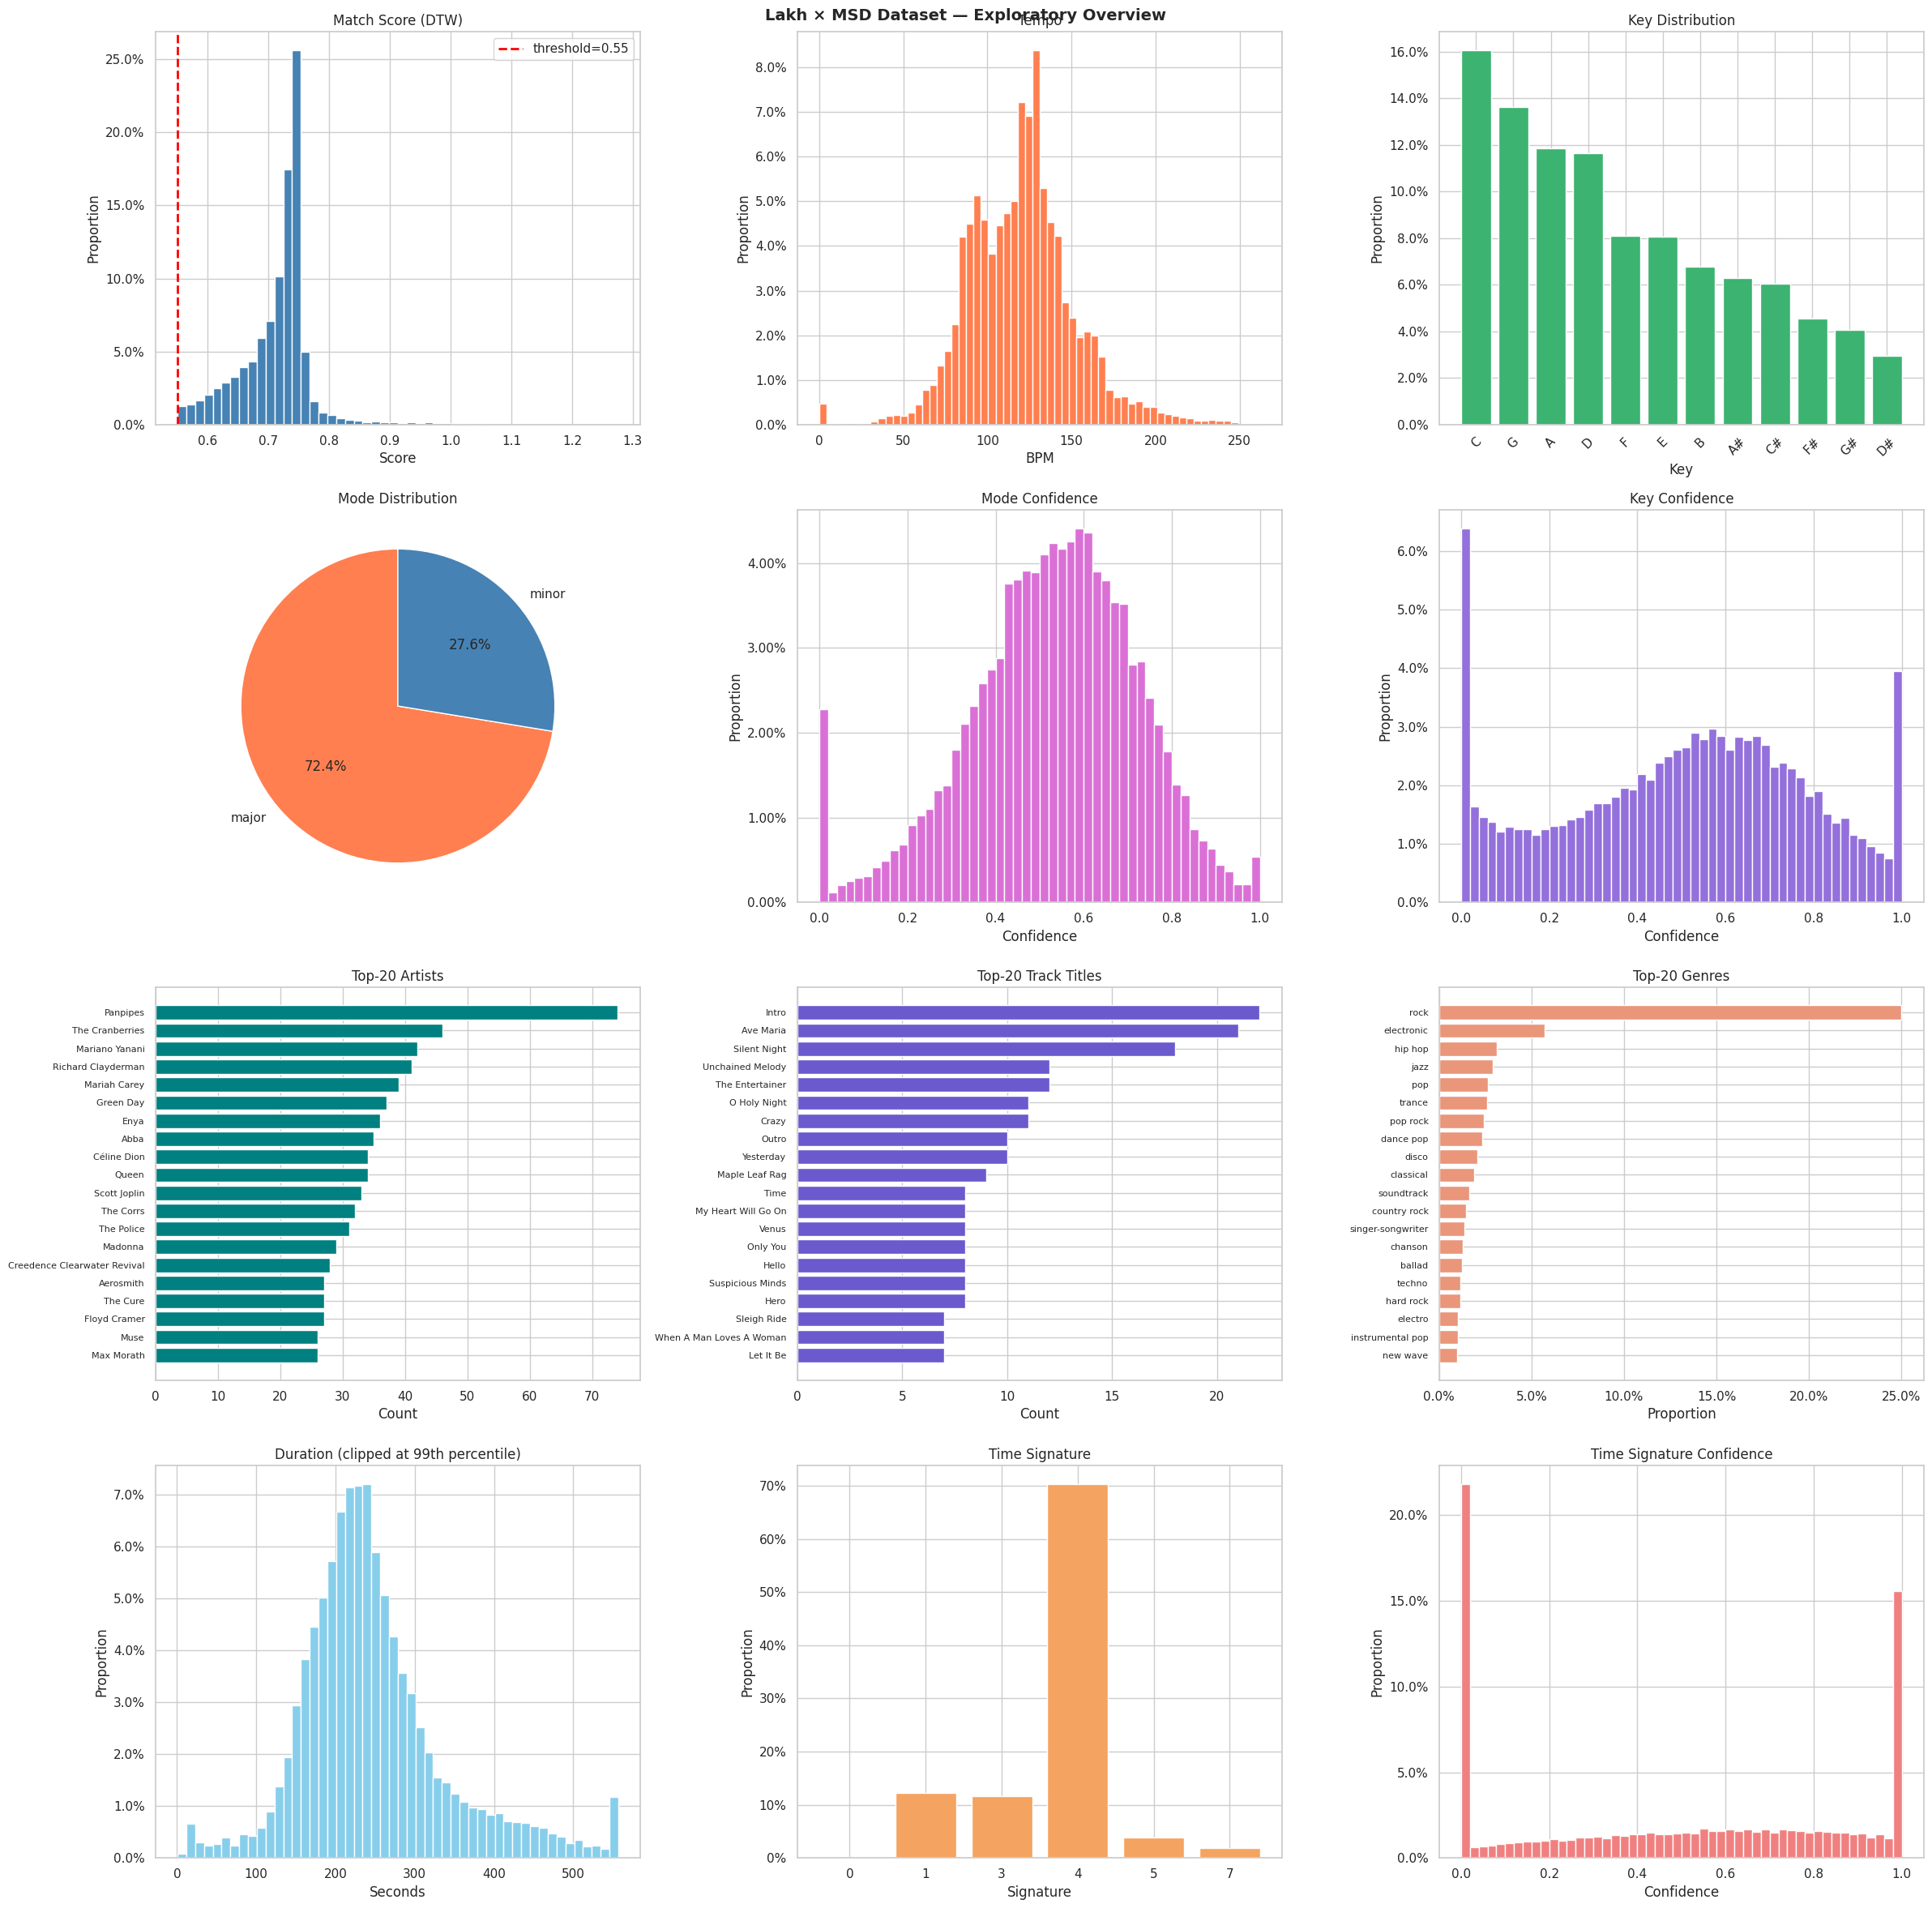

,value
metric,
# tracks parsed,"18,859 (99.1% of dataset)"
mean # instrument tracks / file,10.08
median # instrument tracks / file,10
% files containing drums,85.2%
# unique instrument names seen,129


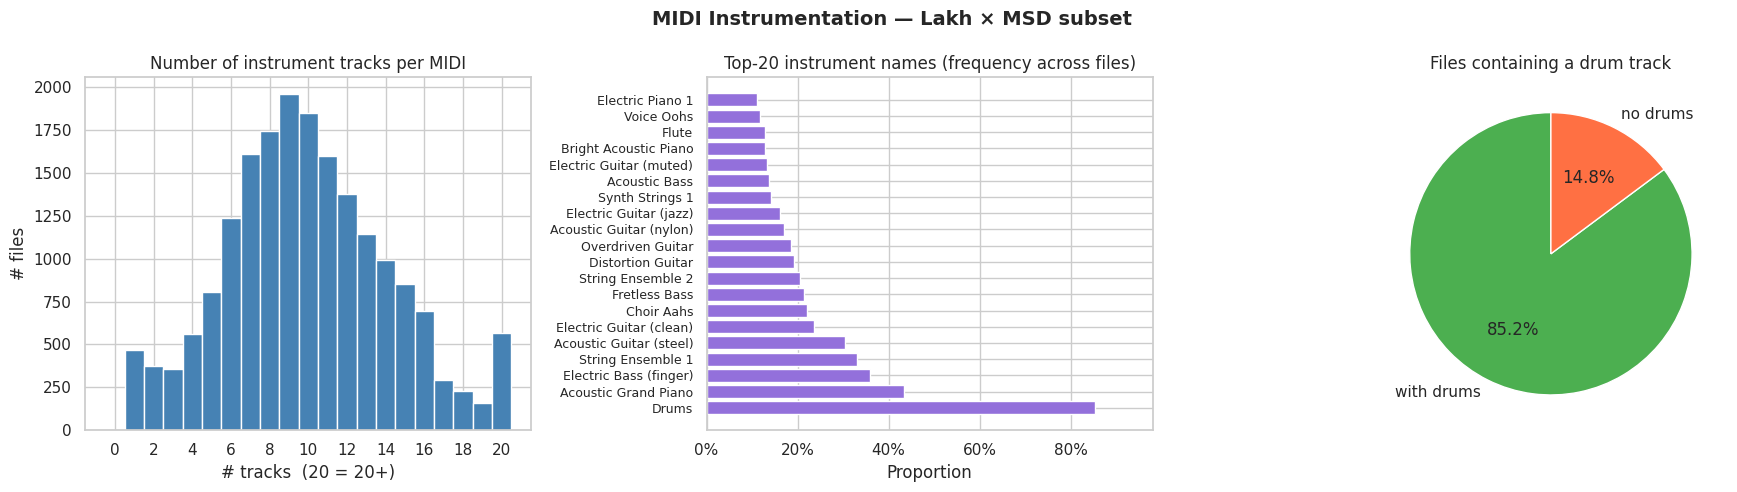

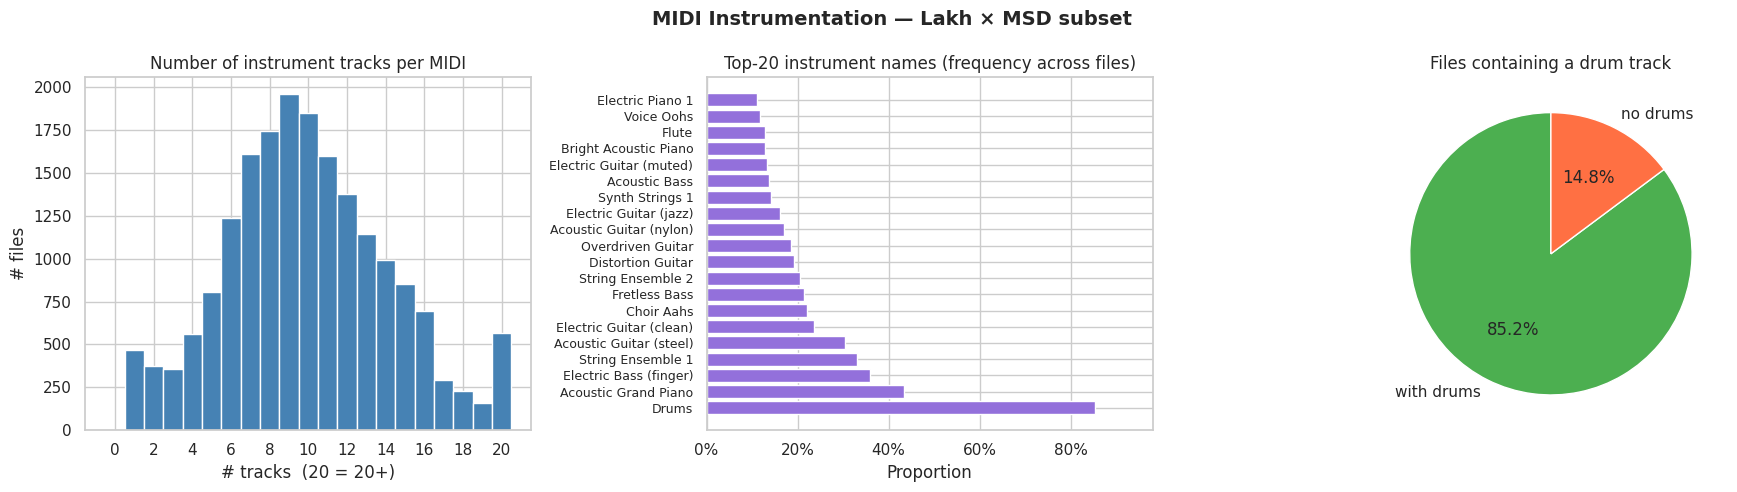

In [6]:
from data.eda import plot_lakh_overview, plot_midi_instrumentation

plot_lakh_overview(lakh_df, min_score=0.55)
plot_midi_instrumentation(lakh_df, show=False)

## 2 — User Data Integration
Downloads Echo Nest Taste Profile (train_triplets.txt), removes mismatch songs, intersects with LMD, cold-start filters (≥ 5 plays/user), saves filtered parquet.

In [7]:
from data.dataset_extraction import (
    load_taste_profile, load_sid_mismatches,
    filter_taste_profile, build_user_song_stats,
)

TRIPLETS_TXT = RAW / "train_triplets.txt"
MISMATCHES   = RAW / "sid_mismatches.txt"

# ── 2.1 Download (once) ──────────────────────────────────────────────────────
if not SKIP_DOWNLOAD:
    for target in ("triplets", "mismatches"):
        subprocess.run([sys.executable, str(ROOT / "scripts" / "download_user_data.py"),
                        "--dest", str(RAW), "--only", target], check=True)

# ── 2.2 Build or load ────────────────────────────────────────────────────────
if TASTE_PQ.exists() and PER_USER_CSV.exists() and PER_SONG_CSV.exists() and not FORCE_REBUILD:
    taste_df = pd.read_parquet(TASTE_PQ)
    print(f"[SKIP] loaded taste_profile from {TASTE_PQ.relative_to(ROOT)}  shape={taste_df.shape}")
else:
    raw_triplets = load_taste_profile(TRIPLETS_TXT, chunksize=500_000, verbose=True)
    bad_song_ids = load_sid_mismatches(MISMATCHES, verbose=True)
    lmd_song_ids = set(lakh_df["song_id"].dropna().unique())
    taste_df = filter_taste_profile(raw_triplets, bad_song_ids=bad_song_ids,
                                    lmd_song_ids=lmd_song_ids, min_plays_per_user=5, verbose=True)
    stats_d = build_user_song_stats(taste_df, lmd_df=lakh_df)
    taste_df.to_parquet(TASTE_PQ, index=False)
    stats_d["per_user"].reset_index().to_csv(PER_USER_CSV, index=False)
    stats_d["per_song"].reset_index().to_csv(PER_SONG_CSV, index=False)
    print(f"saved → {TASTE_PQ}")

print(f"Taste profile: {len(taste_df):,} interactions  "
      f"users={taste_df['user_id'].nunique():,}  songs={taste_df['song_id'].nunique():,}")

[SKIP] loaded taste_profile from data/processed/taste_profile_filtered.parquet  shape=(3048959, 3)
Taste profile: 3,048,959 interactions  users=299,156  songs=7,227
Taste profile: 3,048,959 interactions  users=299,156  songs=7,227


### 2.1. Exploratory Data Analysis on User Data
This section performs exploratory data analysis (EDA) on the user listening data from the Echo Nest Taste Profile dataset.

             Interactions  Unique Users  Unique Songs
Step                                                 
Raw              48373586       1019318        384546
−Mismatches      45795100       1019318        378309
∩ LMD             4243384        848243          7465
−Cold-start       3048959        299156          7227


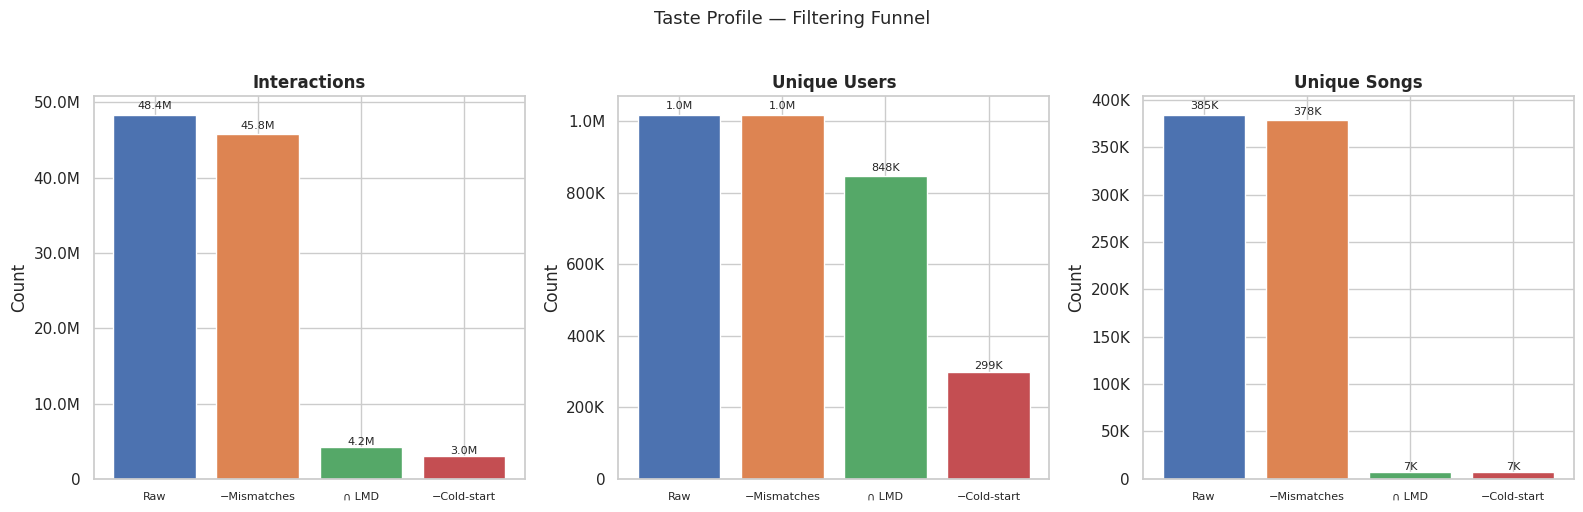

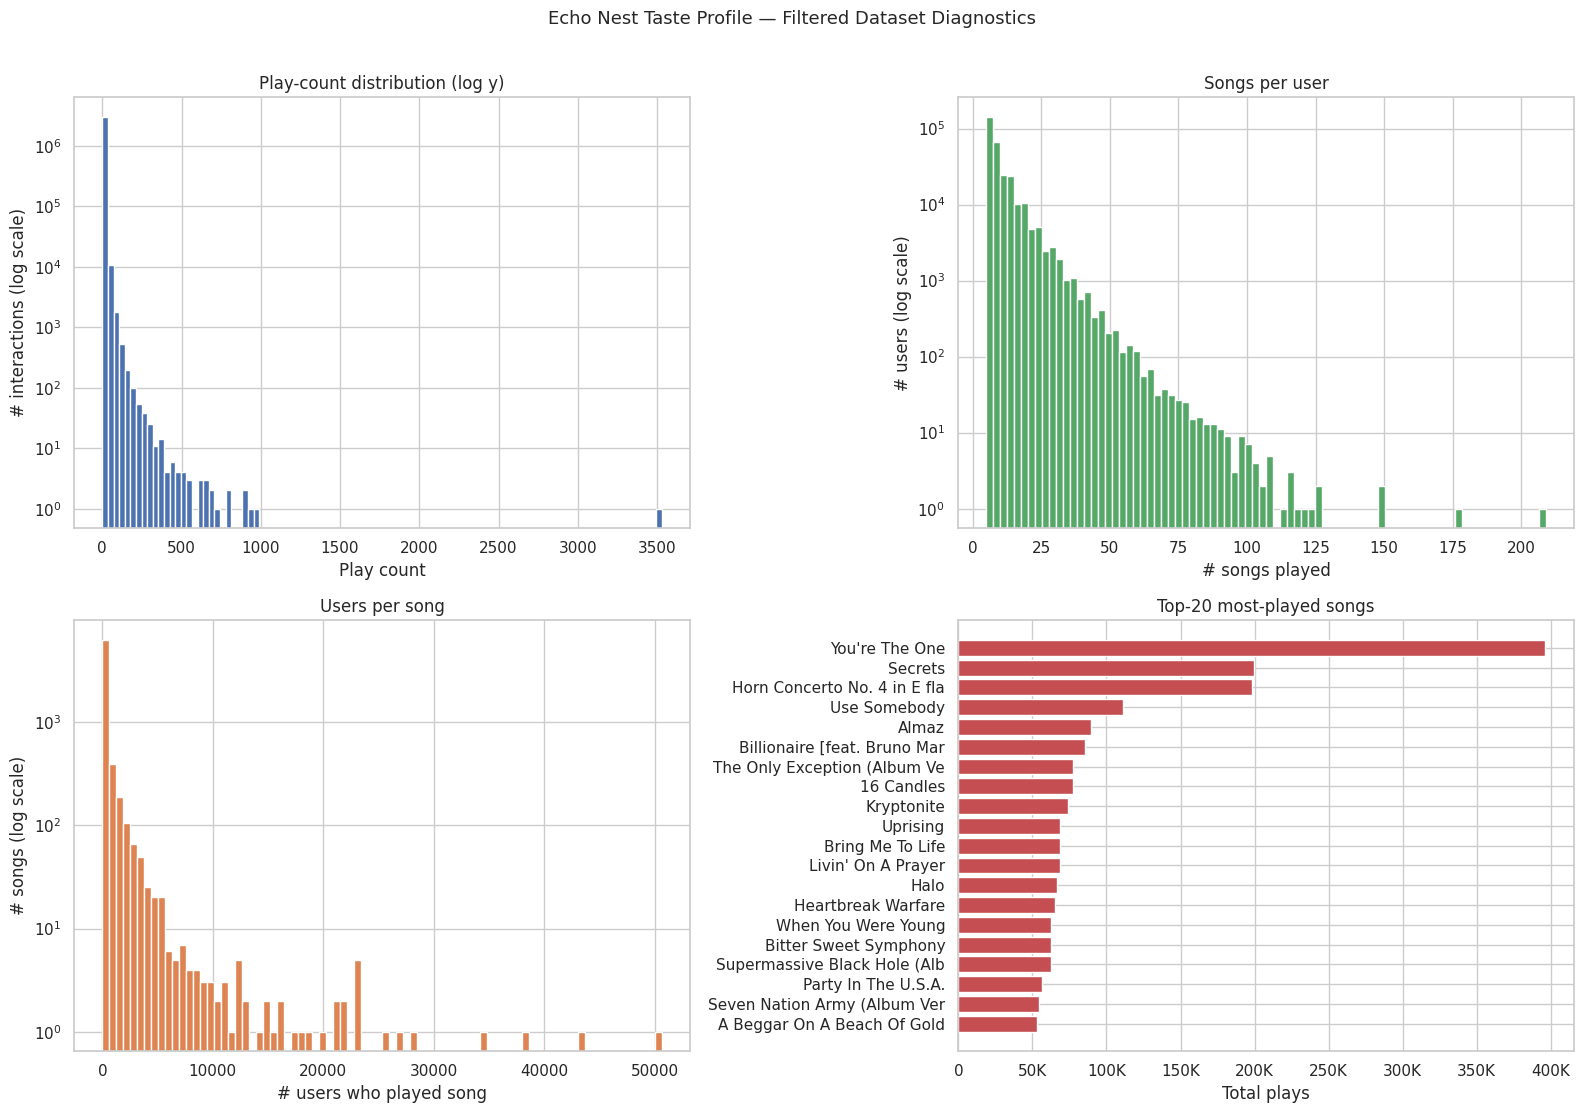

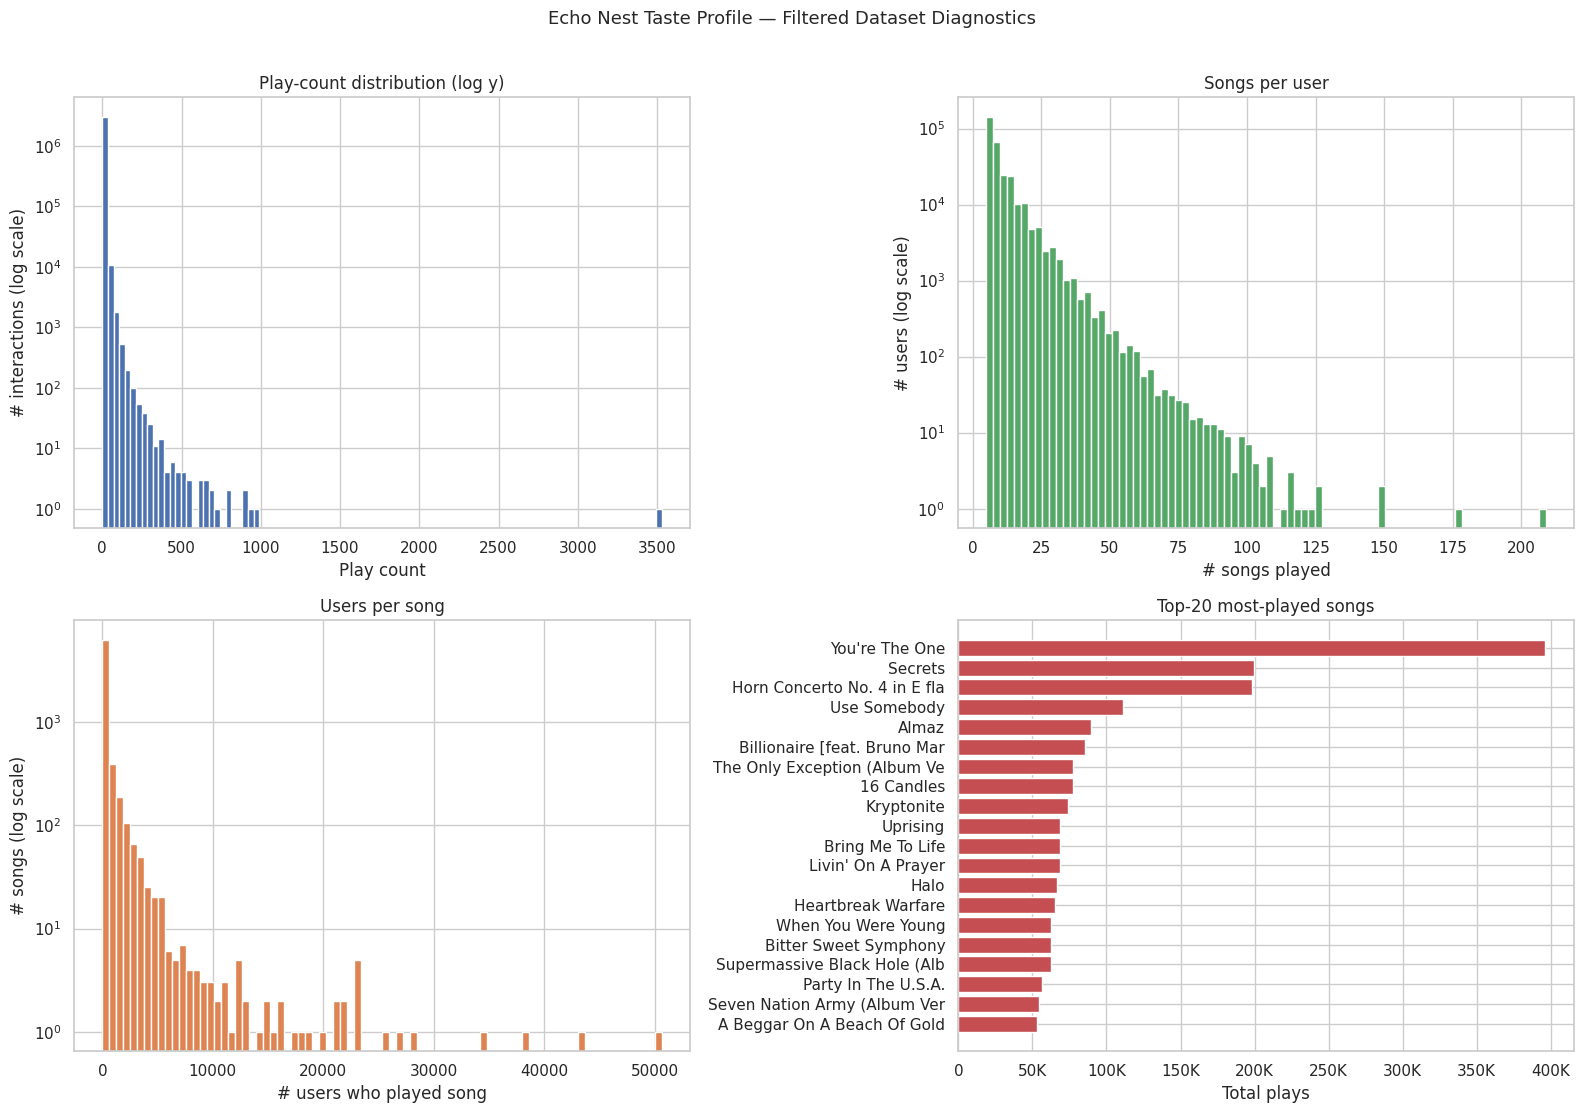

In [8]:
from data.eda import plot_user_funnel, plot_user_diagnostics

# taste_df.attrs["filter_stats"] is populated by filter_taste_profile()
plot_user_funnel(taste_df.attrs.get("filter_stats", {}))

per_user_df = pd.read_csv(PER_USER_CSV, index_col="user_id")
per_song_df = pd.read_csv(PER_SONG_CSV, index_col="song_id")
plot_user_diagnostics(taste_df, per_user_df, per_song_df)

## 3 — Music Feature Extraction (jSymbolic)
Only jSymbolic features were successfully extracted. `interim.csv` maps MIDI file paths → 519 numeric features. We load it and align song_ids via MIDI hash.

In [9]:
def _load_jsymbolic_with_song_ids(interim_csv: Path, lakh: pd.DataFrame) -> pd.DataFrame:
    """Load interim.csv, map MIDI hash → song_id, return features indexed by song_id."""
    raw = pd.read_csv(interim_csv)
    raw.rename(columns={raw.columns[0]: "raw_path"}, inplace=True)
    raw["midi_hash"] = raw["raw_path"].apply(
        lambda x: (m := re.search(r"([a-f0-9]{32})\.mid", str(x))) and m.group(1)
    )
    raw = raw.dropna(subset=["midi_hash"])
    lakh_lookup = (
        lakh[["midi_path", "song_id"]].copy()
        .assign(midi_hash=lambda d: d["midi_path"].apply(
            lambda x: (m := re.search(r"([a-f0-9]{32})\.mid", str(x))) and m.group(1)
        ))
        .dropna(subset=["midi_hash", "song_id"])
        .drop_duplicates("midi_hash")
    )
    merged = raw.merge(lakh_lookup[["midi_hash", "song_id"]], on="midi_hash", how="inner")
    feat_cols = [c for c in merged.columns if c not in ("raw_path", "midi_hash", "song_id")]
    result = merged[["song_id"] + feat_cols].drop_duplicates("song_id").set_index("song_id")
    return result.apply(pd.to_numeric, errors="coerce")

if not INTERIM_CSV.exists():
    raise FileNotFoundError(
        f"{INTERIM_CSV} not found. Run the jSymbolic extraction pipeline first "
        "(see notebooks/01_music_features_extraction.ipynb)."
    )

jsym_df = _load_jsymbolic_with_song_ids(INTERIM_CSV, lakh_df)
print(f"jSymbolic features: {jsym_df.shape[0]:,} songs × {jsym_df.shape[1]} features")
print(f"NaN rate: {jsym_df.isnull().mean().mean():.1%}")
jsym_df.head(2)

jSymbolic features: 7,013 songs × 1495 features
NaN rate: 0.0%


,Basic_Pitch_Histogram_0,Basic_Pitch_Histogram_1,Basic_Pitch_Histogram_2,Basic_Pitch_Histogram_3,Basic_Pitch_Histogram_4,Basic_Pitch_Histogram_5,Basic_Pitch_Histogram_6,Basic_Pitch_Histogram_7,Basic_Pitch_Histogram_8,Basic_Pitch_Histogram_9,Basic_Pitch_Histogram_10,Basic_Pitch_Histogram_11,Basic_Pitch_Histogram_12,Basic_Pitch_Histogram_13,Basic_Pitch_Histogram_14,Basic_Pitch_Histogram_15,Basic_Pitch_Histogram_16,Basic_Pitch_Histogram_17,Basic_Pitch_Histogram_18,Basic_Pitch_Histogram_19,Basic_Pitch_Histogram_20,Basic_Pitch_Histogram_21,Basic_Pitch_Histogram_22,Basic_Pitch_Histogram_23,Basic_Pitch_Histogram_24,Basic_Pitch_Histogram_25,Basic_Pitch_Histogram_26,Basic_Pitch_Histogram_27,Basic_Pitch_Histogram_28,Basic_Pitch_Histogram_29,Basic_Pitch_Histogram_30,Basic_Pitch_Histogram_31,Basic_Pitch_Histogram_32,Basic_Pitch_Histogram_33,Basic_Pitch_Histogram_34,Basic_Pitch_Histogram_35,Basic_Pitch_Histogram_36,Basic_Pitch_Histogram_37,Basic_Pitch_Histogram_38,Basic_Pitch_Histogram_39,Basic_Pitch_Histogram_40,Basic_Pitch_Histogram_41,Basic_Pitch_Histogram_42,Basic_Pitch_Histogram_43,Basic_Pitch_Histogram_44,Basic_Pitch_Histogram_45,Basic_Pitch_Histogram_46,Basic_Pitch_Histogram_47,Basic_Pitch_Histogram_48,Basic_Pitch_Histogram_49,Basic_Pitch_Histogram_50,Basic_Pitch_Histogram_51,Basic_Pitch_Histogram_52,Basic_Pitch_Histogram_53,Basic_Pitch_Histogram_54,Basic_Pitch_Histogram_55,Basic_Pitch_Histogram_56,Basic_Pitch_Histogram_57,Basic_Pitch_Histogram_58,Basic_Pitch_Histogram_59,Basic_Pitch_Histogram_60,Basic_Pitch_Histogram_61,Basic_Pitch_Histogram_62,Basic_Pitch_Histogram_63,Basic_Pitch_Histogram_64,Basic_Pitch_Histogram_65,Basic_Pitch_Histogram_66,Basic_Pitch_Histogram_67,Basic_Pitch_Histogram_68,Basic_Pitch_Histogram_69,Basic_Pitch_Histogram_70,Basic_Pitch_Histogram_71,Basic_Pitch_Histogram_72,Basic_Pitch_Histogram_73,Basic_Pitch_Histogram_74,Basic_Pitch_Histogram_75,Basic_Pitch_Histogram_76,Basic_Pitch_Histogram_77,Basic_Pitch_Histogram_78,Basic_Pitch_Histogram_79,Basic_Pitch_Histogram_80,Basic_Pitch_Histogram_81,Basic_Pitch_Histogram_82,Basic_Pitch_Histogram_83,Basic_Pitch_Histogram_84,Basic_Pitch_Histogram_85,Basic_Pitch_Histogram_86,Basic_Pitch_Histogram_87,Basic_Pitch_Histogram_88,Basic_Pitch_Histogram_89,Basic_Pitch_Histogram_90,Basic_Pitch_Histogram_91,Basic_Pitch_Histogram_92,Basic_Pitch_Histogram_93,Basic_Pitch_Histogram_94,Basic_Pitch_Histogram_95,Basic_Pitch_Histogram_96,Basic_Pitch_Histogram_97,Basic_Pitch_Histogram_98,Basic_Pitch_Histogram_99,Basic_Pitch_Histogram_100,Basic_Pitch_Histogram_101,Basic_Pitch_Histogram_102,Basic_Pitch_Histogram_103,Basic_Pitch_Histogram_104,Basic_Pitch_Histogram_105,Basic_Pitch_Histogram_106,Basic_Pitch_Histogram_107,Basic_Pitch_Histogram_108,Basic_Pitch_Histogram_109,Basic_Pitch_Histogram_110,Basic_Pitch_Histogram_111,Basic_Pitch_Histogram_112,Basic_Pitch_Histogram_113,Basic_Pitch_Histogram_114,Basic_Pitch_Histogram_115,Basic_Pitch_Histogram_116,Basic_Pitch_Histogram_117,Basic_Pitch_Histogram_118,Basic_Pitch_Histogram_119,Basic_Pitch_Histogram_120,Basic_Pitch_Histogram_121,Basic_Pitch_Histogram_122,Basic_Pitch_Histogram_123,Basic_Pitch_Histogram_124,Basic_Pitch_Histogram_125,Basic_Pitch_Histogram_126,Basic_Pitch_Histogram_127,Pitch_Class_Histogram_0,Pitch_Class_Histogram_1,Pitch_Class_Histogram_2,Pitch_Class_Histogram_3,Pitch_Class_Histogram_4,Pitch_Class_Histogram_5,Pitch_Class_Histogram_6,Pitch_Class_Histogram_7,Pitch_Class_Histogram_8,Pitch_Class_Histogram_9,Pitch_Class_Histogram_10,Pitch_Class_Histogram_11,Folded_Fifths_Pitch_Class_Histogram_0,Folded_Fifths_Pitch_Class_Histogram_1,Folded_Fifths_Pitch_Class_Histogram_2,Folded_Fifths_Pitch_Class_Histogram_3,Folded_Fifths_Pitch_Class_Histogram_4,Folded_Fifths_Pitch_Class_Histogram_5,Folded_Fifths_Pitch_Class_Histogram_6,Folded_Fifths_Pitch_Class_Histogram_7,Folded_Fifths_Pitch_Class_Histogram_8,Folded_Fifths_Pitch_Class_Histogram_9,Folded_Fifths_Pitch_Class_Histogram_10,Folded_Fifths_Pitch_Class_Histogram_11,Number_of_Pitches,Number_of_Pitch

## 4 — KG Input Preparation
Inner-join lakh_df + jSymbolic features on MIDI hash. Only the ~7,113 tracks with **both** MSD metadata and jSymbolic features enter the KG. Derive `tempo_class`.

In [10]:
from data.kg import (
    DEFAULT_KG_COLUMNS, INTERIM_KG_FEATURES,
    select_kg_columns, load_interim_features, merge_parquet_with_interim,
    load_or_build_kg_taste_profile,
)
from data.kg.tempo_classes import add_tempo_class_column, tempo_class_table

# ── 4.1 Build or load kg_input ───────────────────────────────────────────────
if KG_INPUT_PQ.exists() and not FORCE_REBUILD:
    merged = pd.read_parquet(KG_INPUT_PQ)
    merged = add_tempo_class_column(merged, tempo_col="Mean_Tempo", out_col="tempo_class")
    print(f"[SKIP] loaded kg_input from {KG_INPUT_PQ.relative_to(ROOT)}  shape={merged.shape}")
else:
    kg_df      = select_kg_columns(lakh_df)
    interim_df = load_interim_features(INTERIM_CSV, INTERIM_KG_FEATURES)
    merged     = merge_parquet_with_interim(kg_df, interim_df, midi_path_col="midi_path", how="inner")
    merged     = merged.dropna(subset=["Mean_Tempo"]).reset_index(drop=True)
    merged     = add_tempo_class_column(merged, tempo_col="Mean_Tempo", out_col="tempo_class")
    out = merged.copy(); out["tempo_class"] = out["tempo_class"].astype("string")
    out.to_parquet(KG_INPUT_PQ, index=False)
    print(f"saved → {KG_INPUT_PQ.relative_to(ROOT)}  shape={merged.shape}")

# ── 4.2 Restrict taste profile to KG songs ───────────────────────────────────
kg_song_ids = set(merged["song_id"].dropna().unique())
taste = load_or_build_kg_taste_profile(
    cache_path=KG_TASTE_PQ, taste_source=TASTE_PQ,
    kg_song_ids=kg_song_ids, min_plays_per_user=5, force_rebuild=FORCE_REBUILD,
)
print(f"\nKG: {len(merged):,} tracks  |  KG taste: {len(taste):,} interactions "
      f"({taste['user_id'].nunique():,} users, {taste['song_id'].nunique():,} songs)")

print(f"\nSample of merged KG input ({merged.shape[0]:,} tracks × {merged.shape[1]:,} track attributes):")
display(merged.head())

print(f"\nSample of merged taste ({taste.shape[0]:,} rows × {taste.shape[1]:,} columns):")
display(taste.head())

[SKIP] loaded kg_input from data/interim/kg_input.parquet  shape=(7113, 55)
[user_data] loading cache from /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/interim/kg_taste_profile.parquet

KG: 7,113 tracks  |  KG taste: 2,853,630 interactions (285,037 users, 7,010 songs)

Sample of merged KG input (7,113 tracks × 55 track attributes):

KG: 7,113 tracks  |  KG taste: 2,853,630 interactions (285,037 users, 7,010 songs)

Sample of merged KG input (7,113 tracks × 55 track attributes):


,track_id,midi_path,song_id,artist_id,artist_mbid,artist_name,title,album_name,key,key_confidence,mode,mode_confidence,time_signature,time_signature_confidence,loudness,year,primary_genre,top3_genres,artist_terms,artist_terms_weight,midi_n_instruments,midi_instrument_names,midi_md5,Mean_Melodic_Interval,Amount_of_Arpeggiation,Repeated_Notes,Chromatic_Motion,Stepwise_Motion,Average_Length_of_Melodic_Arcs,Average_Interval_Spanned_by_Melodic_Arcs,Melodic_Pitch_Variety,Chord_Duration,Standard_Triads,Dominant_Seventh_Chords,Initial_Tempo,Mean_Tempo,Tempo_Variability,Note_Density,Note_Density_Variability,Average_Note_Duration,Variability_of_Note_Durations,Amount_of_Staccato,Rhythmic_Variability,Polyrhythms,String_Keyboard_Prevalence,Acoustic_Guitar_Prevalence,Electric_Guitar_Prevalence,Brass_Prevalence,Woodwinds_Prevalence,Average_Number_of_Independent_Voices,Variability_of_Number_of_Independent_Voices,Voice_Equality_-_Number_of_Notes,Variation_of_Dynamics,Average_Note_to_Note_Change_in_Dynamics,tempo_class
0,TRAAAGR128F425B14B,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,SONRWUU12AF72A4283,ARGE7G11187FB37E05,7bd9e20e-74b9-446a-a2ed-a223f82a36e7,Cyndi Lauper,Into The Nightlife,Bring Ya To The Brink,A,0.608,minor,0.495,4,0.800,-7.322,2008.0,new wave,"[new wave, rock, pop]","[new wave, rock, pop, ballad, soundtrack]","[1.0, 0.8274088968810257, 0.8362373810229121, ...",16.0,"[Shamisen, Electric Guitar (muted), Pan Flute,...",b97c529ab9ef783a849b896816001748,3.933,0.7482,0.35040,0.02917,0.1662,1.411,8.025,3.922,0.1793,0.46620,0.008214,122.0,122.00,5.832000e-10,33.18,12.660,0.1543,0.3067,0.675700,0.01800,0.5000,0.020870,0.00000,0.12870,0.01361,0.01717,3.766,2.152,557.70,26.410,13.070,Allegro
1,TRAABVM128F92CA9DC,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,SOXLBJT12A8C140925,ARYKCQI1187FB3B18F,eeacb319-8d4c-48e0-80a0-944e71c375bf,Tesla,Caught In A Dream,Gold,G,0.725,major,0.756,4,0.931,-5.271,2004.0,hard rock,"[hard rock, rock, heavy metal]","[hard rock, rock, heavy metal, classic rock, b...","[1.0, 0.8962468895285768, 0.9755238307281503, ...",15.0,"[Electric Bass (finger), Lead 1 (square), Shak...",39d6c288e1bd93d4705e7a86555347da,3.118,0.6719,0.51200,0.04023,0.1583,1.831,9.067,2.600,0.1986,0.46700,0.020890,74.0,73.95,7.986000e-01,14.41,6.755,0.5721,1.4220,0.614500,0.02773,0.3333,0.155100,0.00000,0.17370,0.00000,0.00000,4.001,1.562,418.80,19.690,13.590,Adagio
2,TRAADKW128E079503A,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,SOJCRUY12A67ADA4C2,ARAO91X1187B98CCA4,1129817c-488a-4096-80c1-77fc1b107c93,Tracy Chapman,Fast Car (LP Version),Tracy Chapman,D,0.018,major,0.261,4,0.171,-15.164,1988.0,rock,"[rock, folk rock, singer-songwriter]","[rock, folk rock, singer-songwriter, soul, aco...","[0.8181959428402149, 1.0, 0.901262729637085, 0...",8.0,"[Electric Bass (finger), Acoustic Guitar (stee...",72cae5077339f6abaee4cad318b1e923,2.602,0.6632,0.37150,0.12850,0.2778,1.926,7.569,3.788,0.3785,0.46440,0.000000,105.0,105.00,3.823000e-12,15.71,5.869,0.4188,0.3141,0.001136,0.03346,0.2500,0.000000,0.30000,0.08182,0.00000,0.22610,5.859,1.658,65.25,9.977,3.734,Andante
3,TRAAEEH128E0795DFE,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,SODHVES12A6701CE6B,AR3793X1187FB50CB3,c707b37e-cb5c-4694-be4d-46beefcb2475,Chris Rea,Driving Home For Christmas,The Road To Hell Part 2,A,0.222,major,0.403,4,0.000,-8.531,1986.0,singer-songwriter,"[singer-songwriter, rock, pop rock]","[singer-songwriter, rock, pop rock, soft rock,...","[0.9366488896509841, 0.8746915765113531, 0.973...",9.0,"[Bright Acoustic Piano, Fretless Bass, Electri...",893d879dc7b254eca10c2e522386e6cf,6.103,0.5128,0.05839,0.01934,0.1887,1.580,10.200,4.073,0.2467,0.02087,0.013400,91.0,91.00,2.430000e-12,28.57,9.630,0.3699,0.6955,0.473400,0.02356,0.7500,0.230900,0.16420,0.03411,0.03781,0.00000,4.988,1.154,861.60,12.120,10.060,Andante
4,TRAAEJH128E0785506,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,SOFBGBL12A67020D9F,ARA870V1187FB3C4B7,1d8010a0-b642-4c8f-9c8d-8dc66b7bb81a,Hank Willi


Sample of merged taste (2,853,630 rows × 3 columns):


,user_id,song_id,play_count
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODACBL12A8C13C273,1
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODXRTY12AB0180F3B,1
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOIZAZL12A6701C53B,5
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SORWLTW12A670208FA,1
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOUKXIN12A8C133C7F,1


In [11]:
tempo_class_table()

,tempo_class,min_bpm,max_bpm,description
0,Larghissimo,0.0,20.0,Extremely slow (< 20 BPM)
1,Grave,20.0,40.0,Slow and solemn (20–40 BPM)
2,Largo,40.0,60.0,Very slow (40–60 BPM)
3,Adagio,60.0,76.0,Slow and stately (60–76 BPM)
4,Andante,76.0,108.0,Walking pace (76–108 BPM)
5,Moderato,108.0,120.0,Moderately (108–120 BPM)
6,Allegro,120.0,168.0,Fast (120–168 BPM)
7,Presto,168.0,200.0,Very fast (168–200 BPM)
8,Prestissimo,200.0,inf,Very very fast (≥ 200 BPM)


## 5 — Knowledge Graph Construction & Enrichment
Builds `MusicRecSyst_populated.ttl` (rich) + `_simple.ttl` via `KGBuilder`, then enriches with Wikidata (SKOS genres/instruments/decades). Listening events are written as streaming N-Triples sidecars to avoid OOM.

In [12]:
from data.kg import KGBuilder

# ── 5.1 Populate rich KG ─────────────────────────────────────────────────────
if ONTO_OUT.exists() and not FORCE_REBUILD:
    builder = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT, overwrite_copy=False)
    print(f"[SKIP] loaded rich KG from {ONTO_OUT.relative_to(ROOT)}")
    display(builder.stats())
else:
    builder = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT, overwrite_copy=True)
    builder.add_music_concept_hierarchy()   # upper WD hierarchy first
    builder.add_tempo_class_individuals()
    builder.add_key_mode_individuals()
    counts = builder.populate_from_dataframe(merged, max_rows=None, verbose=True)
    builder.save()
    print(f"saved → {ONTO_OUT.relative_to(ROOT)}  ({ONTO_OUT.stat().st_size/1024:,.1f} KiB)")

populate: 100%|██████████| 7.11k/7.11k [00:10<00:00, 666row/s, artists=3338, perf=6059, tracks=6059]  



KG population summary: {'artists': 3668, 'tracks': 7013, 'performances': 7013, 'genres': 645, 'instruments': 129, 'rows_skipped': 0}
saved → data/final/MusicRecSyst_populated.ttl  (11,828.2 KiB)
saved → data/final/MusicRecSyst_populated.ttl  (11,828.2 KiB)


In [13]:
from data.kg import (
    INSTRUMENT_ROOT, GENRE_ROOT,
    resolve_labels, build_parent_graph, fetch_qid_metadata,
    enrich_graph_with_wikidata,
    unique_decades_from_dataframe, resolve_decades,
    collect_decade_qids_for_metadata, add_decades_to_graph,
)
from data.kg.kg_builder import _iter_strings
WD_INSTR_PQ        = INTERIM / "wikidata_instruments.json"
WD_INSTR_CHAINS_PQ = INTERIM / "wikidata_instrument_chains.json"
WD_GENRE_PQ        = INTERIM / "wikidata_genres.json"
WD_GENRE_CHAINS_PQ = INTERIM / "wikidata_genre_chains.json"
WD_QID_META_PQ     = INTERIM / "wikidata_qid_metadata.json"
WD_DECADES_PQ      = INTERIM / "wikidata_decades.json"

if RUN_WIKIDATA:
    # ── 5.2 Collect unique labels ─────────────────────────────────────────────
    instr_labels: set[str] = set()
    for cell in merged["midi_instrument_names"]:
        instr_labels.update(_iter_strings(cell))
    genre_labels: set[str] = set()
    for col in ("primary_genre", "top3_genres", "artist_terms"):
        for cell in merged[col]:
            genre_labels.update(([cell.strip()] if isinstance(cell, str) and cell.strip()
                                  else _iter_strings(cell)))
    print(f"  Labels collected — instruments: {len(instr_labels):,}  |  genres: {len(genre_labels):,}")

    # ── 5.3 Resolve labels → QIDs ────────────────────────────────────────────
    instr_map = resolve_labels(sorted(instr_labels), INSTRUMENT_ROOT,
                               cache_path=WD_INSTR_PQ, force_refresh=FORCE_REBUILD_WD, parallel=6, verbose=True)
    genre_map = resolve_labels(sorted(genre_labels),  GENRE_ROOT,
                               cache_path=WD_GENRE_PQ, force_refresh=FORCE_REBUILD_WD, parallel=10, verbose=True)
    print(f"  QIDs resolved   — instruments: {sum(v is not None for v in instr_map.values()):,}"
          f"  |  genres: {sum(v is not None for v in genre_map.values()):,}")

    # ── 5.3b Parent graphs (BFS, direct edges only) ───────────────────────────
    # build_parent_graph stores only direct parents per QID and expands BFS
    # until the domain root, so multi-parent DAGs (e.g. EDM → trance AND dance)
    # are represented correctly without duplicating shared ancestors.
    instr_chains = build_parent_graph(
                           leaf_qids=[q for q in instr_map.values() if q], type_root=INSTRUMENT_ROOT,
                           cache_path=WD_INSTR_CHAINS_PQ, force_refresh=FORCE_REBUILD_WD, parallel=10, verbose=True)
    genre_chains = build_parent_graph(
                           leaf_qids=[q for q in genre_map.values()  if q], type_root=GENRE_ROOT,
                           cache_path=WD_GENRE_CHAINS_PQ, force_refresh=FORCE_REBUILD_WD, parallel=10, verbose=True)

    # ── 5.3c QID metadata ────────────────────────────────────────────────────
    # In the new format every node (leaf + ancestor) is a key in the dict,
    # so union of .keys() gives the full set of QIDs that need metadata.
    all_qids: set[str] = {q for q in (*instr_map.values(), *genre_map.values()) if q}
    all_qids.update(instr_chains.keys())
    all_qids.update(genre_chains.keys())
    qid_metadata = fetch_qid_metadata(sorted(all_qids),
                            cache_path=WD_QID_META_PQ,
                            force_refresh=FORCE_REBUILD_WD, parallel=6, batch_size=50)
    print(f"  Metadata fetched — {len(qid_metadata):,} QIDs  |  graph nodes: instr={len(instr_chains):,}  genre={len(genre_chains):,}")

    # ── 5.4 Enrich KG ────────────────────────────────────────────────────────
    enrich_counts = enrich_graph_with_wikidata(
                            builder, instrument_map=instr_map, genre_map=genre_map,
                            instrument_chains=instr_chains, genre_chains=genre_chains,
                            qid_metadata=qid_metadata, add_hierarchy=True, verbose=False)
    print(f"  KG enriched     — instrument links: {enrich_counts.get('instrument_links', 0):,}"
          f"  |  genre links: {enrich_counts.get('genre_links', 0):,}"
          f"  |  broader edges: {enrich_counts.get('broader_edges', 0):,}")

    # ── 5.5 Decades ──────────────────────────────────────────────────────────
    decade_starts    = unique_decades_from_dataframe(merged, year_col="year")
    decade_qids      = resolve_decades(decade_starts,
                                cache_path=WD_DECADES_PQ,
                                force_refresh=FORCE_REBUILD_WD, parallel=4, verbose=False)
    decade_meta_qids = collect_decade_qids_for_metadata(decade_qids)
    qid_metadata     = fetch_qid_metadata(decade_meta_qids,
                                cache_path=WD_QID_META_PQ,
                                force_refresh=FORCE_REBUILD_WD, parallel=4, batch_size=50, verbose=False)
    decade_counts = add_decades_to_graph(
                            builder, merged, year_col="year", track_id_col="track_id",
                            decade_qids=decade_qids, qid_metadata=qid_metadata, verbose=False)
    print(f"  Decades added   — {len(decade_qids):,} decade QIDs"
          f"  |  track links: {decade_counts.get('track_links', 0) if isinstance(decade_counts, dict) else '?':,}")

    # ── 5.6 Save ─────────────────────────────────────────────────────────────
    builder.save()
    print(f"\n[SAVED] enriched KG → {ONTO_OUT.name}  ({ONTO_OUT.stat().st_size / 1024:,.1f} KiB)")

  Labels collected — instruments: 129  |  genres: 645
[wikidata] loaded 129 cached label->QID entries from wikidata_instruments.json
[wikidata] resolving 0 new labels (type_root=Q110295396, workers=6) ...
[wikidata] cache -> /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/interim/wikidata_instruments.json
[wikidata] loaded 645 cached label->QID entries from wikidata_genres.json
[wikidata] resolving 0 new labels (type_root=Q188451, workers=10) ...
[wikidata] cache -> /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/interim/wikidata_genres.json
  QIDs resolved   — instruments: 67  |  genres: 471
[wikidata] loaded 157 parent-graph entries from wikidata_instrument_chains.json
[wikidata] loaded 548 parent-graph entries from wikidata_genre_chains.json
[wikidata] loaded 716 cached QID-metadata entries from wikidata_qid_metadata.json
[wikidata] fetching metadata for 0 new QIDs (workers=6, batch=50) ...
  Metadata fetched — 716 QIDs  |  graph nodes: inst

In [14]:
from data.kg import stream_users_to_ntriples
LOAD_SIMPLE = True
LOAD_SIMPLE_USERS = False
# ── 5.6 Listening sidecar (rich) ─────────────────────────────────────────────
if LISTENING_NT.exists() and not FORCE_REBUILD:
    print(f"[SKIP] listening sidecar exists: {LISTENING_NT.relative_to(ROOT)} "
          f"({LISTENING_NT.stat().st_size/1024/1024:,.1f} MiB)")
else:
    builder.save()
    listening_counts = stream_users_to_ntriples(
        builder, taste, sidecar_path=LISTENING_NT, merged=merged,
        batch_size=100_000, flush_every=1_000_000, verbose=True,
    )
    builder.save()
    print("listening (rich):", listening_counts)
    print(f"sidecar → {LISTENING_NT.relative_to(ROOT)}  ({LISTENING_NT.stat().st_size/1024/1024:,.1f} MiB)")

# ── 5.7 Simple KG variant ────────────────────────────────────────────────────
if ONTO_OUT_SIMPLE.exists() and LISTENING_NT_SIM.exists() and not FORCE_REBUILD:
    if LOAD_SIMPLE:
        builder_simple = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT_SIMPLE, 
                                overwrite_copy=False, simple=True)
        print(f"Loaded simple KG: {len(builder_simple.g)} triples")
        if LOAD_SIMPLE_USERS:
            builder_simple.g.parse(str(LISTENING_NT_SIM), format="nt")
            print(f"Loaded simple listening sidecar: {len(builder_simple.g)} triples")
        else:
            print(f"[SKIP] simple listening sidecar exists: {LISTENING_NT_SIM.relative_to(ROOT)}")
    print(f"[SKIP] simple variant exists: {ONTO_OUT_SIMPLE.relative_to(ROOT)}")

else:
    builder_simple = KGBuilder(base_ttl=ONTO_BASE, out_ttl=ONTO_OUT_SIMPLE,
                                overwrite_copy=True, simple=True)
    builder_simple.add_tempo_class_individuals()
    builder_simple.populate_from_dataframe(merged, max_rows=None, verbose=False)
    builder_simple.save()
    stream_users_to_ntriples(builder_simple, taste, sidecar_path=LISTENING_NT_SIM,
                              merged=merged, simple=True, batch_size=100_000, verbose=True)
    builder_simple.save()
    print(f"saved simple → {ONTO_OUT_SIMPLE.name} + {LISTENING_NT_SIM.name}")

listening→nt: 100%|██████████| 2.85M/2.85M [00:26<00:00, 107krow/s, interactions=2853630, listeners=285037, orphan=0]



[listening→nt] wrote 2,853,630 interactions for 285,037 listeners (orphaned rows: 0) -> /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/final/MusicRecSyst_listening.nt (1,509.6 MiB)
listening (rich): {'listeners': 285037, 'interactions': 2853630, 'orphan_songs': 0}
sidecar → data/final/MusicRecSyst_listening.nt  (1,509.6 MiB)
listening (rich): {'listeners': 285037, 'interactions': 2853630, 'orphan_songs': 0}
sidecar → data/final/MusicRecSyst_listening.nt  (1,509.6 MiB)


listening→nt: 100%|██████████| 2.85M/2.85M [00:22<00:00, 124krow/s, interactions=2853630, listeners=285037, orphan=0]



[listening→nt] wrote 2,853,630 interactions for 285,037 listeners (orphaned rows: 0) -> /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/final/MusicRecSyst_listening_simple.nt (716.3 MiB)
saved simple → MusicRecSyst_populated_simple.ttl + MusicRecSyst_listening_simple.nt
saved simple → MusicRecSyst_populated_simple.ttl + MusicRecSyst_listening_simple.nt


### 5.1. SPARQL Queries on the KG
This section demonstrates how to run SPARQL queries on the constructed knowledge graph using the `sparql_query` function from `data.eda`. We execute pre-built queries to analyze the KG content, such as retrieving tracks by tempo class and listing top genres.

In [15]:
from data.eda import sparql_query

# ── Pair 1: Top genres by weight ──────────────────────────────────────────────
# SIMPLE — only a count of artists per genre (no weight exists)
QUERY_GENRES_SIMPLE = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
SELECT ?genreLabel (COUNT(DISTINCT ?artist) AS ?n_artists)
WHERE {
    ?artist mrc:hasGenre ?g .
    ?g      skos:prefLabel ?genreLabel .
    FILTER(LANG(?genreLabel) = "en")
}
GROUP BY ?genreLabel
ORDER BY DESC(?n_artists)
LIMIT 10
"""

# RICH — weighted sum across all artist-genre associations
# The blank node (_:assoc) is the only way to reach the weight.
# Without it we could only count, not rank by affinity.
QUERY_GENRES_RICH = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
SELECT ?genreLabel
       (COUNT(DISTINCT ?artist)  AS ?n_artists)
       (ROUND(SUM(?w) * 1000) / 1000 AS ?total_weight)
       (ROUND(AVG(?w) * 1000) / 1000 AS ?avg_weight)
WHERE {
    ?artist mrc:hasGenreAssoc ?assoc .   # <── blank node
    ?assoc  mrc:genre         ?g ;
            mrc:weight        ?w .       # <── only reachable via blank node
    ?g      skos:prefLabel    ?genreLabel .
    FILTER(LANG(?genreLabel) = "en")
}
GROUP BY ?genreLabel
ORDER BY DESC(?total_weight)
LIMIT 10
"""


# ── Discovery: find a valid track that has key+mode in each variant ───────────
QUERY_FIND_TRACK_SIMPLE = """
PREFIX mrc: <http://purl.org/ontology/mrc/>
PREFIX dct: <http://purl.org/dc/terms/>
SELECT ?title_URI ?title WHERE {
    ?title_URI a mrc:MSDTrack ;
               dct:title  ?title ;
               mrc:hasKey  ?k ;
               mrc:hasMode ?m .
} LIMIT 1
"""

QUERY_FIND_TRACK_RICH = """
PREFIX mrc: <http://purl.org/ontology/mrc/>
PREFIX mo:  <http://purl.org/ontology/mo/>
PREFIX dct: <http://purl.org/dc/terms/>
SELECT ?title_URI ?title WHERE {
    ?title_URI  a              mrc:MSDTrack ;
                dct:title      ?title .
    ?perf       mrc:hasTrack   ?title_URI ;
                mrc:hasKey     ?k ;
                mrc:hasMode    ?m .
} LIMIT 1
"""

QUERY_FIND_ARTIST_WITH_WEIGHTS = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX foaf: <http://xmlns.com/foaf/0.1/>
SELECT ?artist_URI ?name WHERE {
    ?artist_URI foaf:name         ?name ;
                mrc:hasGenreAssoc ?assoc .
    ?assoc      mrc:weight        ?w .
} LIMIT 1
"""

_simple_track = sparql_query(builder_simple.g, QUERY_FIND_TRACK_SIMPLE)
_rich_track   = sparql_query(builder.g,        QUERY_FIND_TRACK_RICH)
_rich_artist  = sparql_query(builder.g,        QUERY_FIND_ARTIST_WITH_WEIGHTS)

print("Simple track found:")
display(_simple_track)
print("Rich track found:  ")
display(_rich_track)
print("Rich artist found: ")
display(_rich_artist)

# ── Extract the live URIs ──────────────────────────────────────────────────────
_TRACK_URI_SIMPLE  = str(_simple_track["title_URI"].iloc[0])   if not _simple_track.empty  else None
_TRACK_URI_RICH    = str(_rich_track["title_URI"].iloc[0])     if not _rich_track.empty    else None
_ARTIST_URI_RICH   = str(_rich_artist["artist_URI"].iloc[0]) if not _rich_artist.empty else None

print(f"\n_TRACK_URI_SIMPLE : {_TRACK_URI_SIMPLE}")
print(f"_TRACK_URI_RICH   : {_TRACK_URI_RICH}")
print(f"_ARTIST_URI_RICH  : {_ARTIST_URI_RICH}")

# ── Pair 2: redefined with live URIs ─────────────────────────────────────────
QUERY_KEY_MODE_SIMPLE = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX dct:  <http://purl.org/dc/terms/>
SELECT ?title ?keyLabel ?modeLabel
WHERE {{
    BIND(<{track_uri}> AS ?t)
    ?t  dct:title   ?title ;
        mrc:hasKey  ?k ;
        mrc:hasMode ?m .
    OPTIONAL {{ ?k skos:prefLabel ?keyLabel  . FILTER(LANG(?keyLabel)  = "en") }}
    OPTIONAL {{ ?m skos:prefLabel ?modeLabel . FILTER(LANG(?modeLabel) = "en") }}
}}
""".format(track_uri=_TRACK_URI_SIMPLE)

# NOTE: mo:tempo is OPTIONAL — the Performance exists even without tempo data
QUERY_KEY_MODE_RICH = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX mo:   <http://purl.org/ontology/mo/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX dct:  <http://purl.org/dc/terms/>
SELECT ?title ?keyLabel ?modeLabel ?keyConf ?modeConf ?tempo
WHERE {{
    BIND(<{track_uri}> AS ?t)
    ?t    dct:title      ?title .
    ?perf mrc:hasTrack   ?t ;
          mrc:hasKey     ?k ;
          mrc:hasMode    ?m .
    OPTIONAL {{ ?perf mo:tempo          ?tempo    }}
    OPTIONAL {{ ?perf mrc:keyConfidence  ?keyConf  }}
    OPTIONAL {{ ?perf mrc:modeConfidence ?modeConf }}
    OPTIONAL {{ ?k skos:prefLabel ?keyLabel  . FILTER(LANG(?keyLabel)  = "en") }}
    OPTIONAL {{ ?m skos:prefLabel ?modeLabel . FILTER(LANG(?modeLabel) = "en") }}
}}
""".format(track_uri=_TRACK_URI_RICH)

QUERY_ARTIST_GENRE_WEIGHTS_RICH_ONLY = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX foaf: <http://xmlns.com/foaf/0.1/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
SELECT ?artistName ?genreLabel ?weight
WHERE {{
    BIND(<{artist_uri}> AS ?artist)
    ?artist foaf:name         ?artistName ;
            mrc:hasGenreAssoc ?assoc .
    ?assoc  mrc:genre         ?g ;
            mrc:weight        ?weight .
    ?g      skos:prefLabel    ?genreLabel .
    FILTER(LANG(?genreLabel) = "en")
}}
ORDER BY DESC(?weight)
""".format(artist_uri=_ARTIST_URI_RICH)


# ── Pair 3: Confidence-filtered key detection (rich only has a meaningful form)
# SIMPLE — all we can do is retrieve key/mode; no confidence to filter on
QUERY_CONFIDENT_KEYS_SIMPLE = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
SELECT ?keyLabel (COUNT(*) AS ?n)
WHERE {
    ?t a mrc:MSDTrack ;
       mrc:hasKey  ?k .
    ?k skos:prefLabel ?keyLabel .
    FILTER(LANG(?keyLabel) = "en")
}
GROUP BY ?keyLabel
ORDER BY DESC(?n)
LIMIT 12
"""

# RICH — filter to only high-confidence key detections (≥ 0.8).
# In the simple graph mrc:keyConfidence doesn't exist so this is impossible.
QUERY_CONFIDENT_KEYS_RICH = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX mo:   <http://purl.org/ontology/mo/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
SELECT ?keyLabel (COUNT(*) AS ?n_high_confidence)
WHERE {
    ?perf a mo:Performance ;
          mrc:hasKey          ?k ;
          mrc:keyConfidence   ?kc .    # <── only on Performance in rich KG
    FILTER(?kc >= 0.8)                 # impossible to express in simple KG
    ?k skos:prefLabel ?keyLabel .
    FILTER(LANG(?keyLabel) = "en")
}
GROUP BY ?keyLabel
ORDER BY DESC(?n_high_confidence)
LIMIT 12
"""

Simple track found:


,title_URI,title
0,http://purl.org/ontology/mrc/resource/track_TR...,Into The Nightlife


Rich track found:  


,title_URI,title
0,http://purl.org/ontology/mrc/resource/track_TR...,Into The Nightlife


Rich artist found: 


,artist_URI,name
0,http://purl.org/ontology/mrc/resource/artist_A...,Cyndi Lauper



_TRACK_URI_SIMPLE : http://purl.org/ontology/mrc/resource/track_TRAAAGR128F425B14B
_TRACK_URI_RICH   : http://purl.org/ontology/mrc/resource/track_TRAAAGR128F425B14B
_ARTIST_URI_RICH  : http://purl.org/ontology/mrc/resource/artist_ARGE7G11187FB37E05


In [16]:
print("═══ Pair 1 — Genre ranking ════════════════════════════════")
print("SIMPLE (count only):")
display(sparql_query(builder_simple.g, QUERY_GENRES_SIMPLE))
print("\nRICH (weighted):")
display(sparql_query(builder.g, QUERY_GENRES_RICH))

print("\n═══ Pair 2 — Key/mode for one track ══════════════════════")
print("SIMPLE (no confidence):")
display(sparql_query(builder_simple.g, QUERY_KEY_MODE_SIMPLE))
print("\nRICH (+ keyConf / modeConf / tempo):")
display(sparql_query(builder.g, QUERY_KEY_MODE_RICH))

print("\n═══ Rich-only — Artist genre weights ══════════════════════")
display(sparql_query(builder.g, QUERY_ARTIST_GENRE_WEIGHTS_RICH_ONLY))
print("(same query on simple returns 0 rows — blank node doesn't exist)")
display(sparql_query(builder_simple.g, QUERY_ARTIST_GENRE_WEIGHTS_RICH_ONLY))

print("\n═══ Pair 3 — Confidence-filtered key counts ═══════════════")
print("SIMPLE (unfiltered — no confidence available):")
display(sparql_query(builder_simple.g, QUERY_CONFIDENT_KEYS_SIMPLE))
print("\nRICH (only kc ≥ 0.8):")
display(sparql_query(builder.g, QUERY_CONFIDENT_KEYS_RICH))

═══ Pair 1 — Genre ranking ════════════════════════════════
SIMPLE (count only):


,genreLabel,n_artists
0,rock,2117
1,pop,1062
2,electronic,1037
3,pop rock,814
4,hip hop,381
5,jazz,349
6,alternative rock,337
7,indie rock,290
8,disco,282
9,soft rock,277



RICH (weighted):


,genreLabel,n_artists,total_weight,avg_weight
0,rock,2117,1606.847,0.759
1,electronic,1037,695.345,0.671
2,pop,1062,674.199,0.635
3,pop rock,814,533.005,0.655
4,hip hop,381,293.127,0.769
5,jazz,349,252.908,0.725
6,trance,273,217.106,0.795
7,disco,282,216.879,0.769
8,alternative rock,337,215.815,0.64
9,ballad,264,205.558,0.779



═══ Pair 2 — Key/mode for one track ══════════════════════
SIMPLE (no confidence):


...

,artistName,genreLabel,weight



═══ Pair 3 — Confidence-filtered key counts ═══════════════
SIMPLE (unfiltered — no confidence available):


,keyLabel,n



RICH (only kc ≥ 0.8):


,keyLabel,n_high_confidence
0,C,211
1,G,196
2,D,150
3,A,103
4,F,98
5,E,80
6,B,63
7,A#,51
8,C#,50
9,F#,38


### 5.2. Hierarchy & Temporal Structure Inspection

Three targeted SPARQL queries verify that the richer structural claims were
correctly materialised in the graph:

1. **Genre hierarchy** — walks `skos:broader+` from a leaf genre up to the
   Wikidata root (`wd:Q188451 music genre`), showing each hop.
2. **Instrument hierarchy** — same walk for `mo:Instrument` / `wd:Q34379`.
3. **Decade temporal chain** — shows every decade node, its parent century
   (`skos:broader`), and its immediate neighbours (`wdt:P155` / `wdt:P156`).


In [17]:
# ── Hierarchy query helpers ──────────────────────────────────────────────────
# All three queries run on the RICH KG (builder.g).
# Genre and instrument hierarchies use skos:broader+ to traverse the full
# direct-edge-only DAG built by build_parent_graph().  Decades use both
# skos:broader (→ century) and wdt:P155/P156 (← → neighbour decades).

# ── Query A: Genre hierarchy (bottom-up, all hops shown) ─────────────────────
# Picks the 5 genres with the deepest hierarchy and shows each intermediate
# step: local node → WD anchor → parent → grandparent → … → wd:Q188451
QUERY_GENRE_HIERARCHY = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX ex:   <http://purl.org/ontology/mrc/resource/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX wd:   <http://www.wikidata.org/entity/>

SELECT DISTINCT ?parentLabel ?childLabel ?leafLabel 
WHERE {
    # Every local genre concept (ex:genre/...)
    ?leaf skos:inScheme mrc:GenreScheme ;
          rdfs:label    ?leafLabel .
    FILTER(LANG(?leafLabel) = "en")

    # Walk the full broader+ chain — each row is one hop
    ?leaf    skos:broader+  ?child .
    ?child   skos:broader   ?parent .
    OPTIONAL { ?child  rdfs:label ?childLabel  . FILTER(LANG(?childLabel)  = "en") }
    OPTIONAL { ?parent rdfs:label ?parentLabel . FILTER(LANG(?parentLabel) = "en") }
}
ORDER BY ?leafLabel ?childLabel
LIMIT 40
"""

# ── Query B: Instrument hierarchy (same pattern) ─────────────────────────────
QUERY_INSTRUMENT_HIERARCHY = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT DISTINCT ?parentLabel  ?childLabel ?leafLabel
WHERE {
    ?leaf skos:inScheme mrc:InstrumentScheme ;
          rdfs:label    ?leafLabel .
    FILTER(LANG(?leafLabel) = "en")

    ?leaf   skos:broader+  ?child .
    ?child  skos:broader   ?parent .
    OPTIONAL { ?child  rdfs:label ?childLabel  . FILTER(LANG(?childLabel)  = "en") }
    OPTIONAL { ?parent rdfs:label ?parentLabel . FILTER(LANG(?parentLabel) = "en") }
}
ORDER BY ?leafLabel ?childLabel
LIMIT 40
"""

# ── Query C: Decade temporal chain ───────────────────────────────────────────
# For each local decade shows:
#   - its WD exact-match QID label
#   - its parent century label (via skos:broader → century node)
#   - its predecessor decade label (wdt:P155 "follows")
#   - its successor decade label  (wdt:P156 "followed by")
QUERY_DECADE_CHAIN = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX wdt:  <http://www.wikidata.org/prop/direct/>

SELECT ?prevLabel ?decadeLabel ?nextLabel ?centuryLabel 
WHERE {
    ?decade a mrc:Decade ;
            skos:prefLabel ?decadeLabel .
    FILTER(LANG(?decadeLabel) = "en")

    # Parent century
    OPTIONAL {
        ?decade skos:broader ?century .
        OPTIONAL { ?century rdfs:label ?centuryLabel . FILTER(LANG(?centuryLabel) = "en") }
    }

    # Previous decade in the local sequence
    OPTIONAL {
        ?decade wdt:P155 ?prev .
        OPTIONAL { ?prev skos:prefLabel ?prevLabel . FILTER(LANG(?prevLabel) = "en") }
    }

    # Next decade in the local sequence
    OPTIONAL {
        ?decade wdt:P156 ?next .
        OPTIONAL { ?next skos:prefLabel ?nextLabel . FILTER(LANG(?nextLabel) = "en") }
    }
}
ORDER BY ?decadeLabel
"""

In [ ]:
print("═══ A — Genre hierarchy (leaf → WD ancestor hops) ═══════════════════")
_genre_hier = sparql_query(builder.g, QUERY_GENRE_HIERARCHY)
display(_genre_hier)

print("\n═══ B — Instrument hierarchy (leaf → WD ancestor hops) ══════════════")
_instr_hier = sparql_query(builder.g, QUERY_INSTRUMENT_HIERARCHY)
display(_instr_hier)

print("\n═══ C — Decade chain (decade | century | prev | next) ═══════════════")
_decade_chain = sparql_query(builder.g, QUERY_DECADE_CHAIN)
display(_decade_chain)

#TODO STILL ERROR IN THE 'Element of Music' vs "elements of music" in the genre hierarchy 

═══ A — Genre hierarchy (leaf → WD ancestor hops) ═══════════════════


,parentLabel,childLabel,leafLabel
0,musical concept,elements of music,00s
1,Element of Music,music genre,00s
2,elements of music,music genre,00s
3,musical concept,elements of music,60s
4,Element of Music,music genre,60s
5,elements of music,music genre,60s
6,musical concept,elements of music,70s
7,Element of Music,music genre,70s
8,elements of music,music genre,70s
9,musical concept,elements of music,8-bit



═══ B — Instrument hierarchy (leaf → WD ancestor hops) ══════════════


,parentLabel,childLabel,leafLabel
0,squeezebox,accordion,Accordion
1,set of free reeds,accordion,Accordion
2,musical instrument,aerophone,Accordion
3,musical concept,elements of music,Accordion
4,aerophone,free aerophone,Accordion
5,idiophonic interruptive aerophone,free reed aerophone,Accordion
6,interruptive free aerophone,idiophonic interruptive aerophone,Accordion
7,free aerophone,interruptive free aerophone,Accordion
8,musical instrument,keyboard instrument,Accordion
9,elements of music,musical instrument,Accordion



═══ C — Decade chain (decade | century | prev | next) ═══════════════


,prevLabel,decadeLabel,nextLabel,centuryLabel
0,NaN,1950s,1960s,20th century
1,1950s,1960s,1970s,20th century
2,1960s,1970s,1980s,20th century
3,1970s,1980s,1990s,20th century
4,1980s,1990s,2000s,20th century
5,1990s,2000s,2010s,21st century
6,2000s,2010s,NaN,21st century


In [19]:
import gc
from models.kg_to_hetero import extract_dl_artifacts

edge_dict = extract_dl_artifacts(
    builder.g,
    str(INTERIM / "kg_triples.tsv"),
    str(INTERIM / "edge_dict.json"),
)
print(f"[OK] edge_dict written → {INTERIM / 'edge_dict.json'}")
del builder.g, builder_simple.g  # free memory
gc.collect()


ImportError: cannot import name 'load_kg_as_hetero' from 'models.kg_to_hetero' (/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/src/models/kg_to_hetero.py)

## 6 — Baseline: Train / Val / Test Split + KNN Collaborative Filtering
Per-user 70/10/20 split. User–user cosine KNN on binarised interactions. Sweep k ∈ {5…100} on validation, evaluate once on test. Compare against MostPopular baseline.

kg_input    : (7113, 55)    cols incl. tempo_class=True
kg_taste    : (2853630, 3)
Matrix: 284,864 users × 6,054 songs  sparsity=99.8347%

Stratification: 2,186 unique strata over 7,013 songs
  (genre bucketed to top-10 + 'other')
  primary_genre    11 unique  e.g. ['country_rock', 'dance_pop', 'electronic', 'hard_rock', 'hip_hop', 'jazz', '…']
  decade            8 unique  e.g. ['0', '1950', '1960', '1970', '1980', '1990', '…']
  key              12 unique  e.g. ['a', 'a#', 'b', 'c', 'c#', 'd', '…']
  mode              2 unique  e.g. ['major', 'minor']
  tempo_class       8 unique  e.g. ['adagio', 'allegro', 'andante', 'grave', 'largo', 'moderato', '…']

[SAVED] stratified row index → /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/final/splits_stratified.parquet
Train=1,943,681 (68.2%)  Val=348,054 (12.2%)  Test=559,806 (19.6%)  (target 70/10/20)
Final splits written to:
  train → data/final/splits/train.parquet
  val   → data/final/splits/val.parquet
  test  → d

,JS(val||train),JS(test||train)
attribute,,
primary_genre,0.0044,0.0020
decade,0.0030,0.0010
key,0.0039,0.0019
mode,0.0010,0.0005
tempo_class,0.0044,0.0017



══ Top-12 levels per attribute — proportion in each split ═══════════

── PRIMARY_GENRE ──


,train,val,test
primary_genre,,,
rock,0.4483,0.4452,0.4494
other,0.3426,0.3457,0.3415
dance_pop,0.0442,0.0431,0.0436
pop,0.0433,0.0435,0.0431
hip_hop,0.0392,0.0406,0.0394
hard_rock,0.0222,0.0222,0.0227
country_rock,0.0189,0.0184,0.0186
jazz,0.0150,0.0146,0.0150
electronic,0.0119,0.0121,0.0122



── DECADE ──


...

,train,val,test
key,,,
g,0.1272,0.1281,0.1279
c,0.1270,0.1277,0.1273
d,0.1130,0.1117,0.1126
b,0.1068,0.1073,0.1069
a,0.1065,0.1051,0.1062
e,0.1001,0.1003,0.1003
a#,0.0691,0.0705,0.0685
f,0.0631,0.0635,0.0628
c#,0.0624,0.0616,0.0620



── MODE ──


,train,val,test
mode,,,
major,0.6846,0.6859,0.684
minor,0.3154,0.3141,0.316



── TEMPO_CLASS ──


,train,val,test
tempo_class,,,
allegro,0.3934,0.3940,0.3939
andante,0.3491,0.3471,0.3482
moderato,0.1078,0.1073,0.1070
adagio,0.0960,0.0967,0.0965
presto,0.0306,0.0303,0.0311
largo,0.0175,0.0190,0.0176
prestissimo,0.0053,0.0052,0.0054
grave,0.0004,0.0003,0.0004


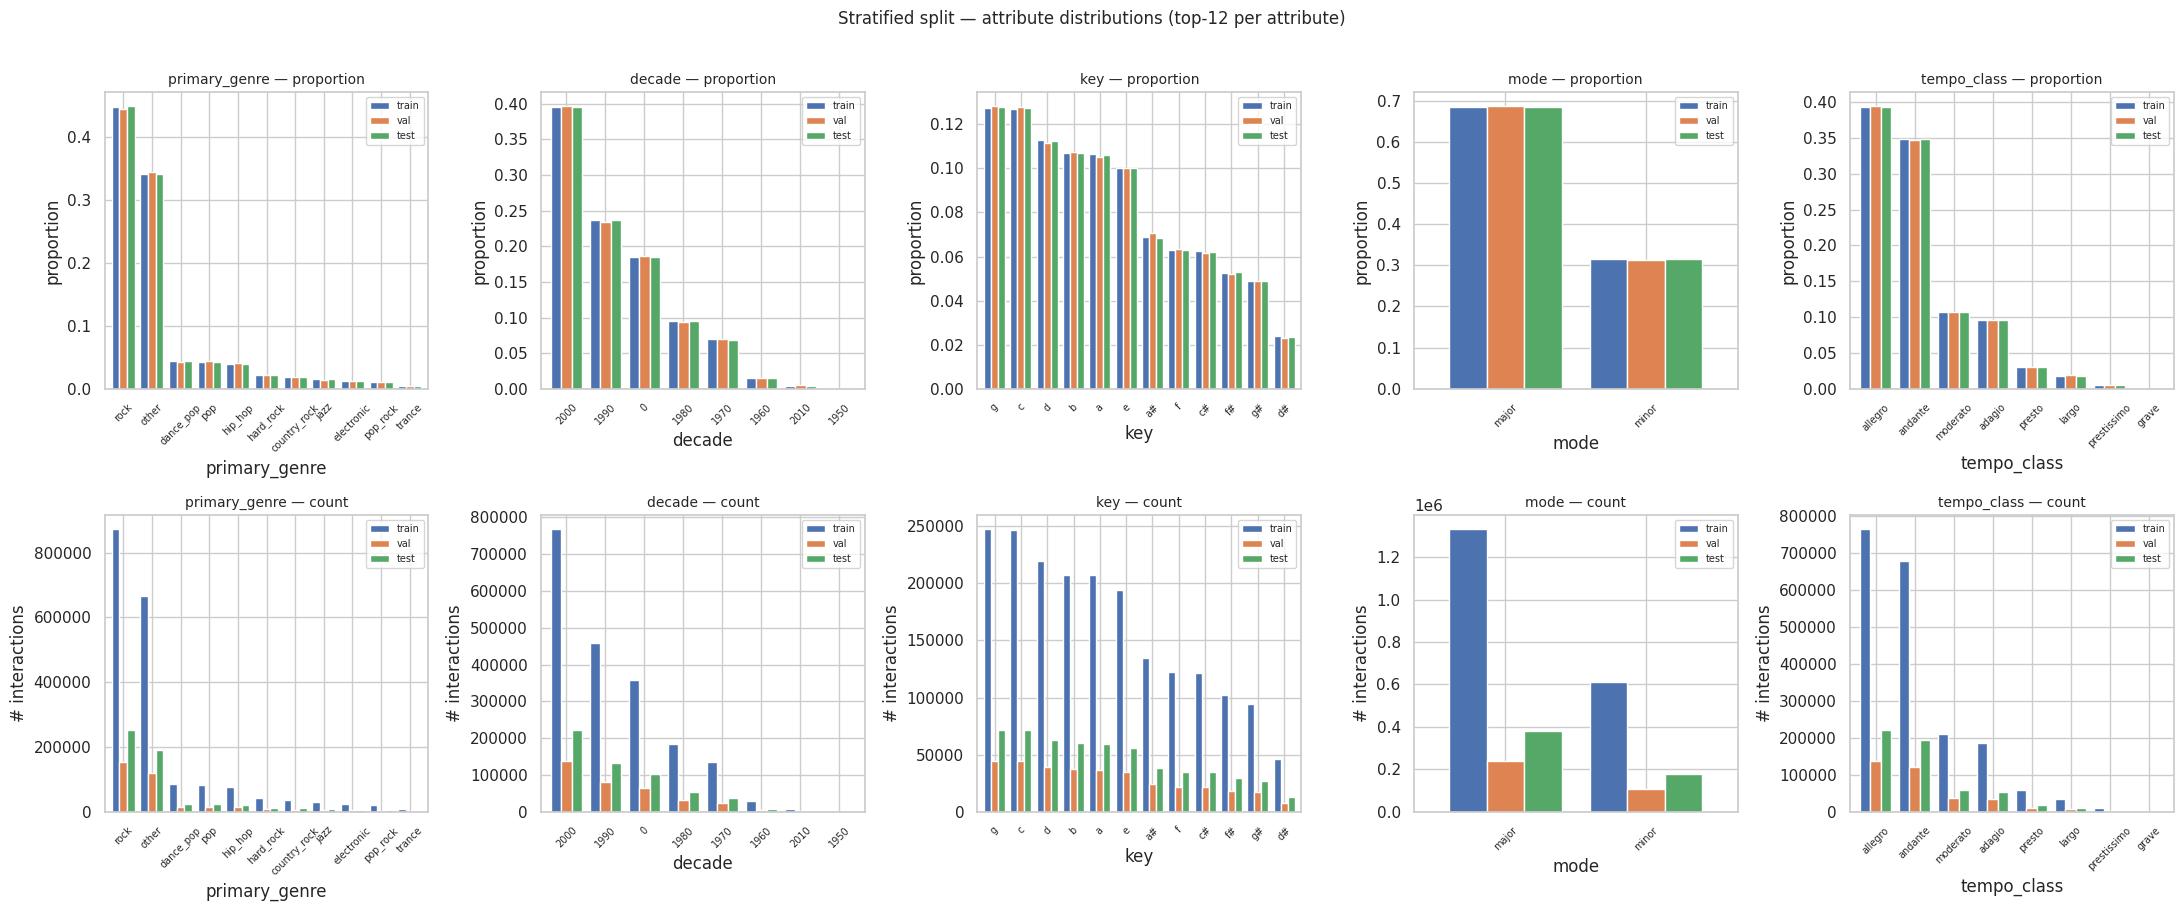

In [ ]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm
from IPython.display import display

# Use the dedicated splitter module so the same logic is reusable from any model
from models.train_val_test_split import (
    DEFAULT_STRATA_ATTRS,
    COARSE_STRATA_ATTRS,
    build_song_strata,
    user_level_stratified_split,
    compute_split_distributions,
    plot_split_distributions,
    save_splits,
    load_splits,
)

TOP_N = 10
K_RANGE = range(5, 101, 5)
MIN_SONGS_PER_USER = 5
MIN_USERS_PER_SONG = 3

# ── 6.1 Encode IDs ───────────────────────────────────────────────────────────
merged_kg = pd.read_parquet(KG_INPUT_PQ)
taste_kg  = pd.read_parquet(KG_TASTE_PQ)
print(f"kg_input    : {merged_kg.shape}    cols incl. tempo_class={'tempo_class' in merged_kg.columns}")
print(f"kg_taste    : {taste_kg.shape}")

df = taste_kg.copy()
song_counts = df.groupby("song_id")["user_id"].nunique()
df = df[df["song_id"].isin(song_counts[song_counts >= MIN_USERS_PER_SONG].index)]
user_counts = df.groupby("user_id")["song_id"].nunique()
df = df[df["user_id"].isin(user_counts[user_counts >= MIN_SONGS_PER_USER].index)]

user_ids = sorted(df["user_id"].unique())
song_ids = sorted(df["song_id"].unique())
user2idx = {u: i for i, u in enumerate(user_ids)}
song2idx = {s: i for i, s in enumerate(song_ids)}
idx2song = {i: s for s, i in song2idx.items()}
df["u_idx"] = df["user_id"].map(user2idx)
df["s_idx"] = df["song_id"].map(song2idx)
N_USERS, N_SONGS = len(user_ids), len(song_ids)
sparsity = 1.0 - len(df) / (N_USERS * N_SONGS)
print(f"Matrix: {N_USERS:,} users × {N_SONGS:,} songs  sparsity={sparsity:.4%}")

# ── 6.2 Per-user STRATIFIED 70/10/20 split ──────────────────────────────────
# Stratification axes: primary_genre × decade × key × mode × tempo_class
#
# Genre treatment:  `primary_genre` has ~272 unique levels.  We keep only the
# TOP_N_GENRES most common labels verbatim; all others are bucketed as "other".
# This halves the strata count (4,448 → ~2,186) with no change to the other
# axes and no loss of information on the dominant genres.
# To use all genres set TOP_N_GENRES = None.
#
# Small-stratum pooling: per-user (user × stratum) groups smaller than
# min_stratum_size=3 are *pooled* and re-split with the target ratios instead
# of being dumped wholesale into train, which recovers ≈70/10/20 globally.
STRATA_ATTRS     = DEFAULT_STRATA_ATTRS   # (primary_genre, decade, key, mode, tempo_class)
TOP_N_GENRES     = 10                     # set None to use all ~272 genres
SPLIT_PQ         = FINAL / "splits_stratified.parquet"
FINAL_SPLITS_DIR = FINAL / "splits"

# Build the song → stratum mapping
song_strata = build_song_strata(merged_kg, attrs=STRATA_ATTRS, top_n_genres=TOP_N_GENRES)
assert song_strata.index.is_unique, "song_strata index must be unique for .map() to work"

# Sanity-check of the per-attribute alphabet
_samp = song_strata.str.split("|", expand=True)
_samp.columns = list(STRATA_ATTRS)
print(f"\nStratification: {song_strata.nunique():,} unique strata over {len(song_strata):,} songs")
print(f"  (genre bucketed to top-{TOP_N_GENRES} + 'other')" if TOP_N_GENRES else "  (all genres)")
for col in _samp.columns:
    vals = sorted(_samp[col].dropna().unique())
    preview = vals[:6] + (["…"] if len(vals) > 6 else [])
    print(f"  {col:<14s} {_samp[col].nunique():>4d} unique  e.g. {preview}")

# ── Splits: load from cache or build ─────────────────────────────────────────
# NOTE: delete data/processed/splits_stratified.parquet (or set FORCE_REBUILD=True)
# if you change TOP_N_GENRES or STRATA_ATTRS, otherwise the cached file is used.
if SPLIT_PQ.exists() and not FORCE_REBUILD:
    splits_df = pd.read_parquet(SPLIT_PQ)
    train_df = df.loc[splits_df[splits_df.split == "train"].row_idx.values].copy()
    val_df   = df.loc[splits_df[splits_df.split == "val"  ].row_idx.values].copy()
    test_df  = df.loc[splits_df[splits_df.split == "test" ].row_idx.values].copy()
    train_df["stratum"] = train_df["song_id"].map(song_strata).fillna("_misc_")
    val_df["stratum"]   = val_df["song_id"].map(song_strata).fillna("_misc_")
    test_df["stratum"]  = test_df["song_id"].map(song_strata).fillna("_misc_")
    print(f"\n[SKIP] loaded stratified splits from {SPLIT_PQ.relative_to(ROOT)}")
else:
    train_df, val_df, test_df = user_level_stratified_split(df, song_strata)
    pd.concat([
        pd.DataFrame({"row_idx": train_df.index, "split": "train"}),
        pd.DataFrame({"row_idx": val_df.index,   "split": "val"}),
        pd.DataFrame({"row_idx": test_df.index,  "split": "test"}),
    ], ignore_index=True).to_parquet(SPLIT_PQ, index=False)
    print(f"\n[SAVED] stratified row index → {SPLIT_PQ}")

total = len(df)
print(f"Train={len(train_df):,} ({len(train_df)/total:.1%})  "
      f"Val={len(val_df):,} ({len(val_df)/total:.1%})  "
      f"Test={len(test_df):,} ({len(test_df)/total:.1%})  "
      f"(target 70/10/20)")

# Persist the actual split DataFrames to data/final/splits/ as parquet
splits_dict = {"train": train_df, "val": val_df, "test": test_df}
saved_paths = save_splits(
    splits_dict, FINAL_SPLITS_DIR, fmt="parquet",
    metadata={
        "attrs": list(STRATA_ATTRS),
        "top_n_genres": TOP_N_GENRES,
        "n_users": N_USERS, "n_songs": N_SONGS,
        "n_strata": int(song_strata.nunique()),
        "kg_input_path": str(KG_INPUT_PQ),
        "kg_taste_path": str(KG_TASTE_PQ),
        "min_users_per_song": MIN_USERS_PER_SONG,
        "min_songs_per_user": MIN_SONGS_PER_USER,
    },
)
print("Final splits written to:")
for k, p in saved_paths.items():
    print(f"  {k:5s} → {p.relative_to(ROOT)}")

# ── 6.2.1 Distribution diagnostics (DataFrames + JS-divergence) ─────────────
distributions = compute_split_distributions(splits_dict, song_strata, attr_names=STRATA_ATTRS)

print("\n══ Jensen-Shannon divergence vs. train  (0 = perfectly balanced) ════")
display(distributions["js_div"])

print("\n══ Top-12 levels per attribute — proportion in each split ═══════════")
for attr, dist_table in distributions["proportion"].items():
    print(f"\n── {attr.upper()} ──")
    display(dist_table.head(12))

# ── 6.2.2 Distribution plots (proportion + count) ───────────────────────────
fig = plot_split_distributions(distributions, top_k=12)
plt.show()

# ── 6.2.3 Build sparse train matrix + ground-truth dicts ────────────────────
train_matrix      = csr_matrix((np.ones(len(train_df)), (train_df["u_idx"].values, train_df["s_idx"].values)),
                                shape=(N_USERS, N_SONGS), dtype=np.float32)
train_matrix_norm = normalize(train_matrix, norm="l2")
song_popularity   = np.asarray(train_matrix.sum(axis=0)).ravel()
pop_norm          = song_popularity / (song_popularity.max() + 1e-9)

def make_gt(split_df): return split_df.groupby("u_idx")["s_idx"].apply(set).to_dict()
val_gt  = make_gt(val_df);  test_gt = make_gt(test_df)
train_seen = train_df.groupby("u_idx")["s_idx"].apply(set).to_dict()
val_users  = sorted(val_gt.keys()); test_users = sorted(test_gt.keys())

# Keep `merged` and `taste` aliases for the rest of the notebook
merged = merged_kg
taste  = taste_kg


### 6.3 — KNN-CF *k*-sweep & evaluation metrics

For every user $u$ with held-out positives $G_u$ and a top-$K$ recommendation list $R_u = (r_1, \ldots, r_K)$ we compute:

- **Recall@K** $= \dfrac{|R_u \cap G_u|}{\min(|G_u|,\, K)}$
- **HitRate@K** $= \mathbb{1}\!\left[R_u \cap G_u \ne \emptyset\right]$
- **MRR** $= \dfrac{1}{\text{rank of first hit}}$ (0 if no hit)
- **DCG@K** $= \displaystyle\sum_{i=1}^{K} \dfrac{\text{hit}_i}{\log_2(i+1)}$, **NDCG@K** $= \dfrac{\text{DCG@K}}{\text{IDCG@K}}$
- **Coverage** $= \dfrac{\left|\bigcup_u R_u\right|}{N_\text{songs}}$
- **PopularityBias** $= \mathrm{mean}\bigl(\text{pop\_norm}[r]\bigr)$ over recommended items.

Model selection uses a composite score that balances accuracy, ranking, catalogue coverage and an inverted popularity bias:

$$
\text{Overall\_Score} = 0.35 \cdot \text{Recall@K} + 0.35 \cdot \text{NDCG@K} + 0.20 \cdot \text{Coverage} + 0.10 \cdot (1 - \text{PopularityBias})
$$

The implementations live in `src/models/evaluation.py` (`dcg`, `evaluate_recs`, `overall_score`) and the full sweep + caching is encapsulated in `src/models/knn_cf.py::run_knn_sweep`.


In [ ]:
from models.evaluation import evaluate_recs, overall_score
from models.knn_cf    import run_knn_sweep

# Run (or load cached) KNN-CF k-sweep on validation, then evaluate the selected k on test.
# Returns the cached neighbour table (nbrs_t, qrow) so downstream cells
# (KNNRecommender, qualitative analysis) can reuse it without re-fitting.
#
# File layout:
#   KNN_VAL_CSV / KNN_TEST_CSV  → data/final/models/knn/   (metrics, gitignored)
#   KNN_NBRS_CACHE              → models/knn/               (binary, gitignored)
val_results_df, test_metrics, best_k, all_nbrs, qrow = run_knn_sweep(
    train_matrix_norm = train_matrix_norm,
    train_seen        = train_seen,
    val_users         = val_users,
    test_users        = test_users,
    val_gt            = val_gt,
    test_gt           = test_gt,
    pop_norm          = pop_norm,
    n_songs           = N_SONGS,
    n_users           = N_USERS,
    k_range           = K_RANGE,
    top_n             = TOP_N,
    train_df          = train_df,
    val_df            = val_df,
    test_df           = test_df,
    val_csv           = KNN_VAL_CSV,
    test_csv          = KNN_TEST_CSV,
    nbrs_cache        = KNN_NBRS_CACHE,
    force_rebuild     = FORCE_REBUILD,
    device            = DEVICE,        # GPU when available, CPU otherwise
)
print(f"all_nbrs shape: {all_nbrs.shape}   |qrow|={len(qrow)}")


k-sweep (val): 100%|██████████| 20/20 [29:50<00:00, 89.53s/it] 


best_k=20  test Recall@10=0.1615  (neighbour cache → knn_cf_val_sweep_results_nbrs.npz)
all_nbrs shape: (284864, 101)   |qrow|=284864


[SAVED] pop/KNN metrics → data/final/models/knn/knn_pop_metrics.csv + data/final/models/knn/knn_pop_metrics.json
KNN vs MostPopular — TEST set
                MostPopular  KNN (k=20)  Δ KNN−Pop
Recall@K             0.1285      0.1615     0.0330
Precision@K          0.0260      0.0328     0.0068
NDCG@K               0.1143      0.1635     0.0492
HitRate@K            0.2002      0.2508     0.0506
MRR                  0.0895      0.1382     0.0487
Coverage             0.0064      0.8548     0.8484
PopularityBias       0.6110      0.2132    -0.3978
Overall_Score        0.1252      0.3634     0.2382
[SAVED] validation sweep plot → data/final/models/knn/knn_val_sweep.png
[SAVED] validation sweep plot → data/final/models/knn/knn_val_sweep.png


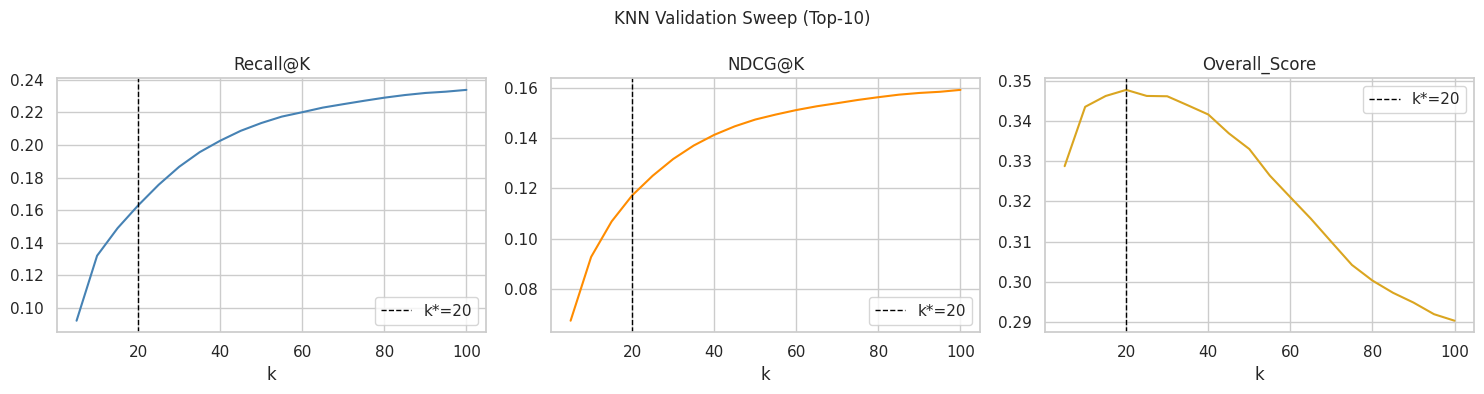

In [ ]:
import json

# ── 6.4  MostPopular baseline + comparison ───────────────────────────────────
if KNN_POP_JSON.exists() and not FORCE_REBUILD:
    with open(KNN_POP_JSON) as f:
        _saved = json.load(f)
    pop_metrics  = _saved["pop_metrics"]
    test_metrics = _saved["test_metrics"]   # re-sync in case the KNN sweep cell was skipped
    best_k       = int(_saved["best_k"])
    comparison   = pd.read_csv(KNN_POP_CSV, index_col=0)
    print(f"[SKIP] loaded pop/KNN metrics from {KNN_POP_JSON.relative_to(ROOT)} + {KNN_POP_CSV.relative_to(ROOT)}")
else:
    pop_rank = np.argsort(-song_popularity)
    pop_recs = {
        u: [int(i) for i in pop_rank if int(i) not in train_seen.get(u, set())][:TOP_N]
        for u in test_users
    }
    pop_metrics = evaluate_recs(pop_recs, test_gt, train_seen, N_SONGS, pop_norm, k=TOP_N)
    pop_metrics["Overall_Score"] = overall_score(pop_metrics)

    comparison = pd.DataFrame(
        {"MostPopular": pop_metrics, f"KNN (k={best_k})": test_metrics}
    ).round(4)
    comparison["Δ KNN−Pop"] = (
        comparison[f"KNN (k={best_k})"] - comparison["MostPopular"]
    ).round(4)

    # ── save ──────────────────────────────────────────────────────────────────
    comparison.to_csv(KNN_POP_CSV)
    with open(KNN_POP_JSON, "w") as f:
        json.dump({"pop_metrics": pop_metrics,
                   "test_metrics": test_metrics,
                   "best_k": best_k}, f, indent=2)
    print(f"[SAVED] pop/KNN metrics → {KNN_POP_CSV.relative_to(ROOT)} + {KNN_POP_JSON.relative_to(ROOT)}")

print("KNN vs MostPopular — TEST set")
print(comparison.to_string())

# ── 6.5  Validation sweep plots ───────────────────────────────────────────────
if KNN_VAL_PLOT_PNG.exists() and not FORCE_REBUILD:
    from IPython.display import Image as IPImage
    print(f"[SKIP] showing saved validation sweep plot from {KNN_VAL_PLOT_PNG}")
    display(IPImage(str(KNN_VAL_PLOT_PNG)))
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (col, color) in zip(axes, [
        ("Recall@K",      "steelblue"),
        ("NDCG@K",        "darkorange"),
        ("Overall_Score", "goldenrod"),
    ]):
        ax.plot(val_results_df.index, val_results_df[col], color=color)
        ax.axvline(best_k, color="black", linestyle="--", linewidth=1,
                   label=f"k*={best_k}")
        ax.set_title(col); ax.set_xlabel("k"); ax.legend()
    plt.suptitle(f"KNN Validation Sweep (Top-{TOP_N})", fontsize=12)
    plt.tight_layout()
    fig.savefig(KNN_VAL_PLOT_PNG, dpi=120, bbox_inches="tight")
    print(f"[SAVED] validation sweep plot → {KNN_VAL_PLOT_PNG.relative_to(ROOT)}")
    plt.show()



### 6.5b — Log baselines as standalone W&B runs

Both **MostPopular** and **KNN-CF** are non-iterative models, so they don't have epoch-by-epoch curves. Instead we create **one short W&B run per baseline** so that, in the W&B project leaderboard, they appear as comparable rows next to the AE/GNN runs. This makes the side-by-side bar charts (`Test_NDCG@10`, `Test_Recall@10`, etc.) generate automatically in the dashboard.


In [ ]:
from utils.wandb_utils import log_baseline_run

_wb_kwargs = dict(
    project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
    n_users=N_USERS, n_songs=N_SONGS, top_n=TOP_N,
)

# MostPopular baseline run
url_pop = log_baseline_run("MostPopular", pop_metrics, **_wb_kwargs)
print(f"  [W&B] 'MostPopular' baseline logged → {url_pop}")

# KNN-CF baseline run
url_knn = log_baseline_run("KNN-CF", test_metrics,
                           extra_config={"best_k": int(best_k)}, **_wb_kwargs)
print(f"  [W&B] 'KNN-CF' baseline logged → {url_knn}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pfanyka/.netrc.


wandb: Currently logged in as: pedro-fanica (pedro-fanica-faculdade-de-ci-ncias-da-universidade-de-lisboa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


test/Coverage,▁
test/HitRate@K,▁
test/MRR,▁
test/NDCG@K,▁
test/Overall_Score,▁
test/PopularityBias,▁
test/Precision@K,▁
test/Recall@K,▁
model_name,MostPopular
test/Coverage,0.00644
test/HitRate@K,0.2002


  [W&B] 'MostPopular' baseline logged → https://wandb.ai/pedro-fanica-faculdade-de-ci-ncias-da-universidade-de-lisboa/music-recommender-system/runs/cwuxkrly


test/Coverage,▁
test/HitRate@K,▁
test/MRR,▁
test/NDCG@K,▁
test/Overall_Score,▁
test/PopularityBias,▁
test/Precision@K,▁
test/Recall@K,▁
model_name,KNN-CF
test/Coverage,0.85481
test/HitRate@K,0.25081


  [W&B] 'KNN-CF' baseline logged → https://wandb.ai/pedro-fanica-faculdade-de-ci-ncias-da-universidade-de-lisboa/music-recommender-system/runs/xnbcwxv2


### 6.6 — Stratified K-Fold Cross-Validation (KNN baseline)
Per-user stratified K-fold (k = 5) on the same genre × decade × key × mode strata. Reports mean ± std for each metric so we know the variance of the baseline before comparing to the GNN.

In [ ]:
from models.knn_cf import _matrix_to_tensor, _find_neighbors_torch, _build_recs_torch

N_FOLDS = 5

def user_level_stratified_kfold(df, song_strata, n_folds=5, seed=42):
    """Per-user, per-stratum round-robin K-fold assignment.
    Returns array of length len(df) with fold ids in 0..n_folds-1."""
    rng = np.random.default_rng(seed)
    df = df.copy()
    df["stratum"] = df["song_id"].map(song_strata).fillna("_misc_")
    fold_assign = np.full(len(df), -1, dtype=np.int8)
    pos = {idx: i for i, idx in enumerate(df.index)}
    for _, grp in df.groupby("u_idx"):
        for _, sgrp in grp.groupby("stratum"):
            idxs = sgrp.index.to_numpy()
            shuffled = rng.permutation(idxs)
            for i, idx in enumerate(shuffled):
                fold_assign[pos[idx]] = i % n_folds
    return pd.Series(fold_assign, index=df.index, name="fold")

if KFOLD_CSV.exists() and not FORCE_REBUILD:
    fold_results_df = pd.read_csv(KFOLD_CSV)
    print(f"[SKIP] loaded K-fold results from {KFOLD_CSV.relative_to(ROOT)}")
else:
    folds = user_level_stratified_kfold(df, song_strata, n_folds=N_FOLDS)
    fold_results = []
    for fold in range(N_FOLDS):
        test_idx  = folds[folds == fold].index
        train_idx = folds[folds != fold].index
        f_train = df.loc[train_idx]; f_test = df.loc[test_idx]

        f_mat = csr_matrix((np.ones(len(f_train)), (f_train["u_idx"].values, f_train["s_idx"].values)),
                           shape=(N_USERS, N_SONGS), dtype=np.float32)
        f_mat_n = normalize(f_mat, norm="l2")
        f_seen  = f_train.groupby("u_idx")["s_idx"].apply(set).to_dict()
        f_gt    = f_test.groupby("u_idx")["s_idx"].apply(set).to_dict()
        f_users = sorted(f_gt.keys())

        # ── PyTorch KNN (GPU when DEVICE == "cuda") ───────────────────────────
        f_train_t = _matrix_to_tensor(f_mat_n, DEVICE)
        f_query_t = f_train_t[torch.tensor(f_users, device=DEVICE)]
        f_nbrs_t  = _find_neighbors_torch(f_query_t, f_train_t,
                                          n_neighbors=best_k + 1)   # (Q, best_k+1)
        f_qrow    = {u: i for i, u in enumerate(f_users)}

        recs = _build_recs_torch(
            best_k, f_users,
            nbrs_tensor=f_nbrs_t, qrow=f_qrow,
            train_tensor=f_train_t, train_seen=f_seen,
            top_n=TOP_N,
        )

        m = evaluate_recs(recs, f_gt, f_seen, N_SONGS)
        m["Overall_Score"] = overall_score(m); m["fold"] = fold
        fold_results.append(m)
        print(f"  fold {fold}:  Recall@{TOP_N}={m['Recall@K']:.4f}  NDCG={m['NDCG@K']:.4f}  Overall={m['Overall_Score']:.4f}")

    fold_results_df = pd.DataFrame(fold_results)
    fold_results_df.to_csv(KFOLD_CSV, index=False)
    print(f"[SAVED] K-fold results → {KFOLD_CSV.relative_to(ROOT)}")

metric_cols = ["Recall@K", "NDCG@K", "HitRate@K", "MRR", "Coverage", "PopularityBias", "Overall_Score"]
summary = fold_results_df[metric_cols].agg(["mean", "std"]).T
summary.columns = ["mean", "std"]
summary["mean ± std"] = summary.apply(lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
print(f"\n══ {N_FOLDS}-Fold CV Summary (KNN k={best_k}, Top-{TOP_N}) ═════════════════════")
print(summary[["mean ± std"]].to_string())

# Plot per-fold variance
fig, ax = plt.subplots(figsize=(10, 4))
plot_metrics = ["Recall@K", "NDCG@K", "HitRate@K", "MRR", "Overall_Score"]
fold_results_df[plot_metrics].plot.bar(ax=ax, width=0.8)
ax.set_xlabel("Fold"); ax.set_ylabel("Score")
ax.set_title(f"Per-fold KNN performance (k={best_k}, stratified by genre×decade×key×mode)")
ax.legend(loc="upper right", bbox_to_anchor=(1.18, 1))
plt.tight_layout(); plt.show()


### 6.7 — Qualitative Analysis: Example User
Pick one user with enough listening history; show (a) their training songs as the *reference profile*, then (b) the top-K KNN recommendations along with their **cosine similarity** to the user's profile vector and to each individual reference song.

In [ ]:
from models.evaluation import (
    PopularityRecommender, KNNRecommender,
    analyze_user, AttributeArrays,
)
from models.evaluation.qualitative_plots import plot_user_distribution_comparison

# ── 6.7.1  Pre-compute the shared attribute lookup arrays (once for every model)
song_meta = (
    merged[["song_id", "title", "artist_name", "primary_genre",
            "year", "key", "mode", "Mean_Tempo", "tempo_class"]]
    .drop_duplicates("song_id").set_index("song_id")
)
attrs = AttributeArrays.from_song_meta(song_meta, idx2song)

# Per-song L2 norms (used by cosine helpers in evaluation.qualitative)
song_vectors = train_matrix_norm.T.tocsr()
song_norms   = np.sqrt(np.asarray(song_vectors.multiply(song_vectors).sum(axis=1)).ravel())

# ── 6.7.2  Build the recommenders (same uniform interface for every model) ──
recs_pop = PopularityRecommender(song_popularity, train_seen)
recs_knn = KNNRecommender(train_matrix_norm, train_seen,
                          all_nbrs=all_nbrs, qrow=qrow,
                          best_k=best_k, pop_norm=pop_norm)
RECOMMENDERS = [recs_pop, recs_knn]   # HGT will be appended in §10.x

# ── 6.7.3  Pick an example user (median listening volume in test set) ───────
user_train_sizes = train_df.groupby("u_idx").size()
candidates = [u for u in test_users if 15 <= user_train_sizes.get(u, 0) <= 60]
example_uidx = int(np.random.default_rng(42).choice(candidates)) if candidates else int(test_users[0])
print(f"Example user: u_idx={example_uidx}  user_id={user_ids[example_uidx]}")
print(f"  train interactions : {user_train_sizes.get(example_uidx, 0)}")
print(f"  test  interactions : {len(test_gt.get(example_uidx, set()))}")

# ── 6.7.4  Per-model qualitative summary for that user ──────────────────────
user_rows = [
    analyze_user(example_uidx, r, top_n=TOP_N,
                 train_seen=train_seen, test_gt=test_gt,
                 attrs=attrs, song_vectors=song_vectors, song_norms=song_norms)
    for r in RECOMMENDERS
]
user_compare = pd.DataFrame(user_rows).set_index("model")
print(f"\n── Per-model summary for u_idx={example_uidx} ──")
display(user_compare.round(4))

# ── 6.7.5  Distribution-shift bar charts (showcased on KNN only) ────────────
def _meta_rows(s_idxs):
    return pd.DataFrame([
        (lambda r: {"genre": r.get("primary_genre"), "mode": r.get("mode"),
                    "tempo_class": r.get("tempo_class"), "year": r.get("year"),
                    "mean_tempo": r.get("Mean_Tempo")})(
            song_meta.loc[idx2song[int(s)]] if idx2song.get(int(s)) in song_meta.index else {})
        for s in s_idxs
    ])

train_meta = _meta_rows(list(train_seen.get(example_uidx, set())))
recs_knn_dict = recs_knn.recommend([example_uidx], TOP_N)[example_uidx]
rec_meta   = _meta_rows(recs_knn_dict)
test_meta  = _meta_rows(list(test_gt.get(example_uidx, set())))

fig_user = plot_user_distribution_comparison(
    train_meta, rec_meta, test_meta,
    title=f"u_idx={example_uidx} — KNN: train vs recs vs test gt",
)
plt.show()


NameError: name 'all_nbrs' is not defined

### 6.8 — Population-Level Qualitative Analysis
Runs the same profile-vs-recommendations comparison across **all test users** to see whether the collaborative-filtering KNN (which saw *only interaction counts*, no music features) produces recommendations whose musical attributes align with what users actually listened to.

For every test user we compare:
- **train** — the user's full training history  
- **recs** — the KNN top-10 recommendations  
- **test gt** — the held-out ground-truth songs

We aggregate: (1) per-user JS-divergence between train and recs distributions, (2) dominant-genre match rate, (3) mode & tempo-class alignment, (4) decade shift, (5) cosine-similarity distribution across all users, and (6) a population-level attribute comparison that shows how faithfully recommendations mirror training profiles — **without any audio features**.


Building attribute lookup arrays … done.
Running population analysis on 284,864 users using 10 threads …
done.
Running population analysis on 284,864 users using 10 threads …


pop-qual: 100%|██████████| 284864/284864 [25:49<00:00, 183.81it/s]



[SAVED] → /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/processed/pop_qual_analysis.csv  (284,864 users)

284,864 test users analysed


,u_idx,n_train,n_test,n_hits,cos_mean,cos_median,cos_max,js_genre,js_mode,js_tempo_class,js_decade,mean_tempo_train,mean_tempo_rec,mean_decade_train,mean_decade_rec,js_genre_test,js_mode_test,js_decade_test
count,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,284864.0000,283633.0000,284864.0000,284864.0000,284864.0000,284864.0000
mean,142431.5000,6.8232,1.9652,0.2601,0.0977,0.0940,0.1410,0.6013,0.1732,0.4028,0.4422,111.0310,107.9247,1991.5547,1992.5920,0.5935,0.3196,0.5253
std,82233.2979,4.9584,1.4392,0.6150,0.0666,0.0644,0.0973,0.1014,0.1271,0.1166,0.1394,13.9605,2.7715,6.7022,1.1945,0.2073,0.2216,0.2050
min,0.0000,2.0000,1.0000,0.0000,0.0000,0.0000,0.0003,0.2731,0.0000,0.0000,0.0000,55.4767,85.5250,1950.0000,1984.2858,0.0000,0.0000,0.0000
25%,71215.7500,4.0000,1.0000,0.0000,0.0307,0.0296,0.0435,0.5349,0.0708,0.3124,0.3439,102.0724,107.3150,1988.0000,1992.0000,0.4645,0.1198,0.3823
50%,142431.5000,5.0000,2.0000,0.0000,0.0939,0.0901,0.1259,0.5887,0.1554,0.3856,0.4401,110.5400,107.3150,1992.5000,1992.0000,0.5938,0.3092,0.5238
75%,213647.2500,9.0000,2.0000,0.0000,0.1533,0.1468,0.2324,0.6424,0.2736,0.4677,0.5423,119.3333,107.3550,1996.6666,1993.3334,0.8326,0.4645,0.6502
max,284863.0000,134.0000,41.0000,8.0000,0.2579,0.2599,0.3915,0.8326,0.8326,0.8326,0.8326,243.7000,126.6600,2010.0000,2000.0000,0.8326,0.8326,0.8326



══════════════════════════════════════════════════════════════════════
 6.8.2  Aggregate JS-divergence — KNN alignment with training profiles
══════════════════════════════════════════════════════════════════════

── JS-divergence (train→recs vs train→test-gt)  lower = more aligned ──
  If JS(train→recs) ≈ JS(train→test-gt), KNN drift mirrors real behaviour.


── JS-divergence (train→recs vs train→test-gt)  lower = more aligned ──
  If JS(train→recs) ≈ JS(train→test-gt), KNN drift mirrors real behaviour.



,,JS mean,JS median,JS p25,JS p75
attribute,comparison,,,,
genre,train vs recs,0.6013,0.5887,0.5349,0.6424
mode,train vs recs,0.1732,0.1554,0.0708,0.2736
tempo_class,train vs recs,0.4028,0.3856,0.3124,0.4677
decade,train vs recs,0.4422,0.4401,0.3439,0.5423
genre,train vs test gt,0.5935,0.5938,0.4645,0.8326
mode,train vs test gt,0.3196,0.3092,0.1198,0.4645
decade,train vs test gt,0.5253,0.5238,0.3823,0.6502



── Dominant-attribute match rates (% of users) ──────────────────────


,match_rate,n_users
attribute,,
genre,62.4%,"177,625 / 284,864"
mode,85.8%,"244,459 / 284,864"



── Cosine similarity (rec → user profile) across all test users ─────


,cos_mean,cos_median,cos_max
count,284864.0000,284864.0000,284864.0000
mean,0.0977,0.0940,0.1410
std,0.0666,0.0644,0.0973
min,0.0000,0.0000,0.0003
25%,0.0307,0.0296,0.0435
50%,0.0939,0.0901,0.1259
75%,0.1533,0.1468,0.2324
max,0.2579,0.2599,0.3915


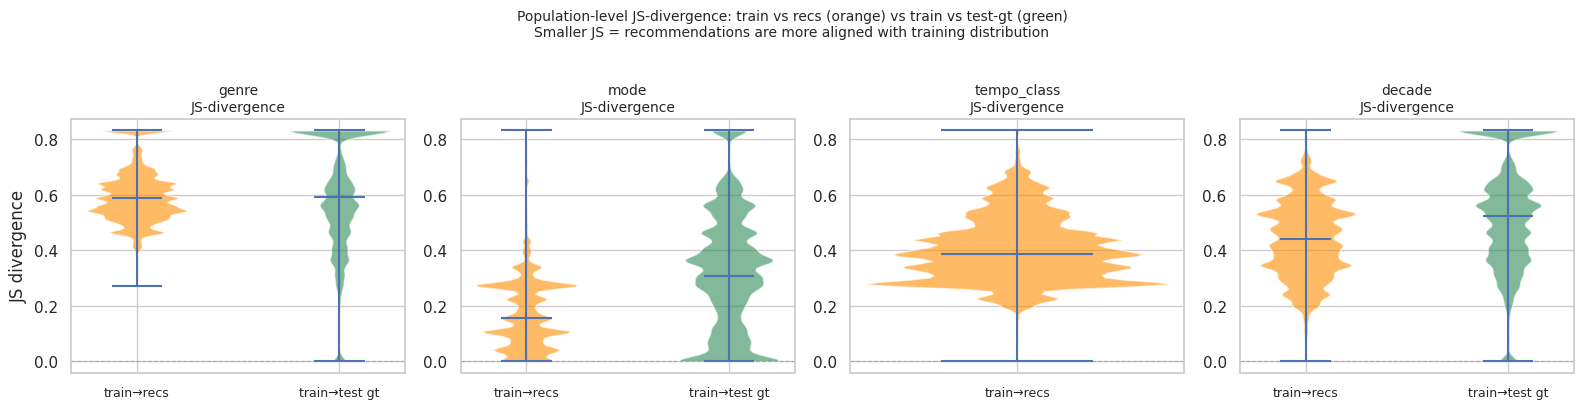

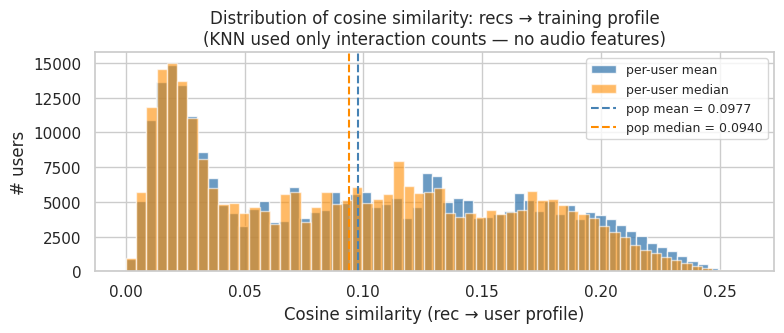

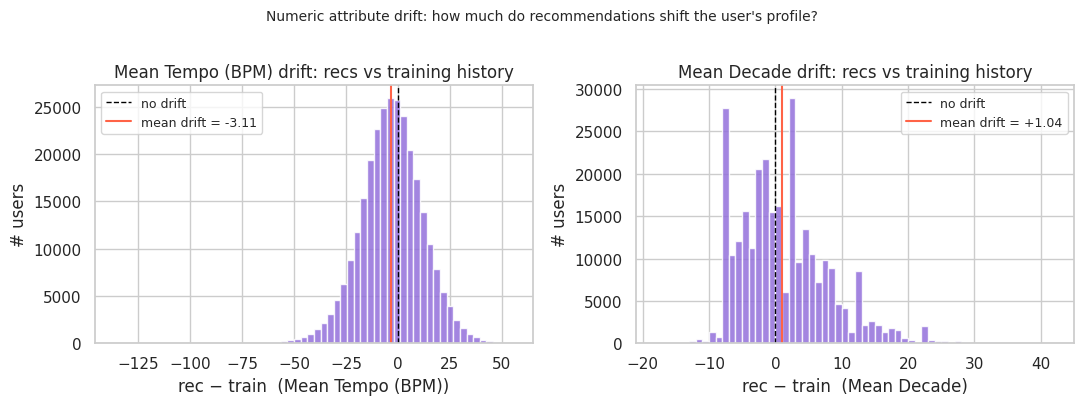

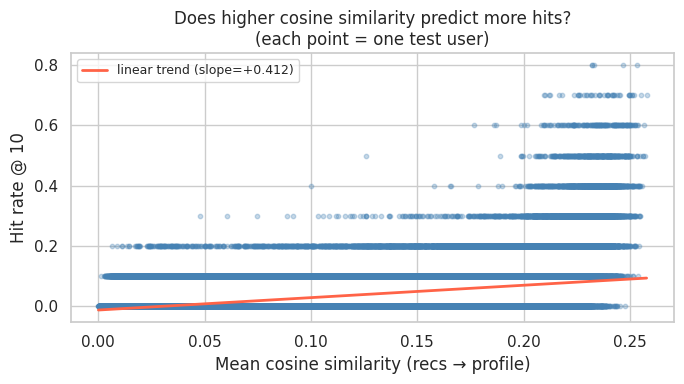


══════════════════════════════════════════════════════════════════════
 6.8.9  Population-level verdict
══════════════════════════════════════════════════════════════════════

  Users with ≥1 hit in top-10       : 20.0%
  Dominant-genre match rate             : 62.4%
  Dominant-mode  match rate             : 85.8%
  Mean JS(genre): train→recs            : 0.6013
  Mean JS(genre): train→test-gt         : 0.5935
  recs vs test-gt genre alignment       : ✓ aligned
  Mean tempo drift  (recs−train)        : -3.1 BPM
  Mean decade drift (recs−train)        : +1.0 years

  → The KNN model — using ONLY interaction counts, zero audio features —
    matched the user's dominant genre in 62.4% of cases and
    produced genre distributions (JS=0.6013) that are at least as
    aligned with the training profile as the users' own held-out test songs.


In [ ]:
from models.evaluation import analyze_population
from models.evaluation.qualitative_plots import plot_population_summary

# ── 6.8.1  Run the population qualitative analysis for every recommender ────
# Cached per model so re-runs are instant.
pop_qual_dfs = {}
for r in RECOMMENDERS:
    cache = PROCESSED / f"pop_qual_{r.name.lower().replace('-','_')}.csv"
    if cache.exists() and not FORCE_REBUILD:
        pop_qual_dfs[r.name] = pd.read_csv(cache)
        print(f"[SKIP] {r.name}: loaded {cache.name} ({len(pop_qual_dfs[r.name]):,} users)")
    else:
        df = analyze_population(
            r, test_users, top_n=TOP_N,
            train_seen=train_seen, test_gt=test_gt, attrs=attrs,
            song_vectors=song_vectors, song_norms=song_norms,
        )
        df.to_csv(cache, index=False)
        pop_qual_dfs[r.name] = df
        print(f"[SAVED] {r.name}: → {cache.name} ({len(df):,} users)")

# ── 6.8.2  Aggregate verdict per model ──────────────────────────────────────
verdict_rows = []
for name, df in pop_qual_dfs.items():
    verdict_rows.append({
        "model":            name,
        "users":            len(df),
        "any_hit_rate":     (df["n_hits"] > 0).mean(),
        "dom_genre_match":  df["dom_genre_match"].mean(),
        "dom_mode_match":   df["dom_mode_match"].mean(),
        "cos_mean":         df["cos_mean"].mean(),
        "js_genre_mean":    df["js_genre"].mean(),
        "js_decade_mean":   df["js_decade"].mean(),
        "tempo_drift_BPM":  (df["mean_tempo_rec"]  - df["mean_tempo_train"]).mean(),
        "decade_drift_yr":  (df["mean_decade_rec"] - df["mean_decade_train"]).mean(),
    })
verdict_df = pd.DataFrame(verdict_rows).set_index("model").round(4)
print("\n── 6.8.2  Population-level verdict (per model) ──")
display(verdict_df)

# ── 6.8.3  Mosaic plot: JS-divergence violins, cosine hist, hit-rate scatter
fig_pop = plot_population_summary(pop_qual_dfs, top_n=TOP_N)
plt.show()


### 6.9 — Multi-K metrics & statistical comparison (baselines)

Evaluate every recommender at several cut-offs $K \in \{5, 10, 20, 50\}$ and compare them with paired statistical tests:

- **Wilcoxon signed-rank** — non-parametric paired test, robust to skewed per-user metric distributions.
- **Paired *t*-test** — for completeness when normality is reasonable.
- **Cohen's** $d_z = \dfrac{\bar{x}_d}{s_d}$ — paired-difference effect size.
- **Friedman + Nemenyi** post-hoc — global omnibus test plus pairwise critical-difference comparison.

All heavy lifting lives in `src/models/evaluation/{metrics, comparison, wandb_log}.py`.


In [ ]:
from models.evaluation import (
    multi_k_evaluation, evaluate_recs_per_user,
    summarise_comparison,
)

K_LIST   = [5, 10, 20, 50]
K_MAX    = max(K_LIST)

# ── 6.9.1  Bulk recommendations at K_MAX, then slice for every K ────────────
bulk_recs   = {r.name: r.recommend(test_users, K_MAX) for r in RECOMMENDERS}

# Long-format multi-K table   (model | K | metric | value)
metrics_long = pd.concat([
    multi_k_evaluation(bulk_recs[name], test_gt, train_seen,
                       N_SONGS, pop_norm, ks=K_LIST, model_name=name)
    for name in bulk_recs
], ignore_index=True)

print("── 6.9.1  Multi-K metrics ──────────────────────────────────────────")
display(metrics_long.pivot_table(index=["model", "metric"],
                                 columns="K", values="value").round(4))

# ── 6.9.2  Per-user metric vectors at TOP_N (used for statistical tests) ────
per_user = {
    name: evaluate_recs_per_user(bulk_recs[name], test_gt, pop_norm, k=TOP_N)
    for name in bulk_recs
}

# ── 6.9.3  Pairwise + global statistical comparison ─────────────────────────
comp = summarise_comparison(per_user,
                            metrics=("Recall@K", "NDCG@K", "MRR", "HitRate@K"))
print("\n── 6.9.2  Pairwise paired-test results ─────────────────────────────")
display(comp["pairwise"].round(5))

print("\n── 6.9.3  Friedman omnibus + best-ranked model per metric ──────────")
fried = pd.DataFrame([{
    "metric":         m,
    "n_users":        r["n_users"],
    "friedman_stat":  r["friedman_stat"],
    "friedman_p":     r["friedman_p"],
    "best_model":     r["mean_ranks"].index[0] if not r["mean_ranks"].empty else "?",
} for m, r in comp["global"].items()])
display(fried.round(5))

# ── 6.9.4  Log everything to W&B as a standalone analysis run ───────────────
import wandb
from models.evaluation.wandb_log import (
    log_multi_k_table, log_population_qualitative,
    log_pairwise_significance, log_global_comparison,
)

eval_run = wandb.init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY, group=WANDB_GROUP,
    job_type="analysis", name="evaluation_baselines",
    tags=["evaluation", "multi-k", "statistical-test"], reinit=True,
)
log_multi_k_table(metrics_long)
log_population_qualitative(pop_qual_dfs)
log_pairwise_significance(comp["pairwise"])
log_global_comparison(comp["global"])
wandb.finish()
print(f"\n[W&B] baseline-evaluation run finished → {eval_run.url}")


## 7. Node features: Embeddings
For the purpose of training the GNN with as much initial knowledge as possible, as opposed to randomly initialize the embeddings, we train an autoencoder to reduce the dimensionality of our music feature vector and also a Knowledge graph embedding algorithm, in this case

In [ ]:
import wandb

# Hyper-parameters and dataset stats logged once for the whole experiment.
# AE + HGT share a single run so their curves live in one dashboard panel.
wandb_config = dict(
    # data
    n_songs              = N_SONGS,
    n_users              = N_USERS,
    top_n_genres         = TOP_N_GENRES,
    strata_attrs         = list(STRATA_ATTRS),
    top_n                = TOP_N,
    # KNN
    best_k               = best_k,
    # autoencoder
    ae_hidden_dims       = [512, 256],
    ae_bottleneck        = 128,
    ae_epochs            = 30,
    ae_batch_size        = 256,
    ae_lr                = 1e-3,
    # HGT — listwise loss + full-graph training
    hgt_hidden           = 128,
    hgt_heads            = 4,
    hgt_layers           = 2,
    hgt_epochs           = 100,
    hgt_lr               = 1e-3,
    hgt_user_batch_size  = 1024,   # users per mini-batch for loss accumulation
    hgt_lambda_reg       = 0.2,    # popularity-debiasing strength
    hgt_temperature      = 0.1,    # softmax temperature
    device               = DEVICE,
    model_type           = "deep",
)

run = wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    group   = WANDB_GROUP,
    job_type= "train",
    name    = f"ae-hgt_k{best_k}_top{TOP_N}",
    config  = wandb_config,
    tags    = ["autoencoder", "hgt", "deep", "listwise-loss"],
    notes   = (
        "Autoencoder on jSymbolic features → HGT trained with debiased listwise loss "
        "(logit-adjustment, full-graph forward, mini-batch accumulation). "
        "Baselines logged separately."
    ),
    reinit  = True,
)

print(f"[W&B] AE+HGT run started → {run.url}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/pfanyka/.netrc.
wandb: Currently logged in as: pedro-fanica (pedro-fanica-faculdade-de-ci-ncias-da-universidade-de-lisboa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


NameError: name 'pop_metrics' is not defined

In [ ]:

from sklearn.preprocessing import StandardScaler
from models.autoencoder import jSymbolicAutoencoder, train_autoencoder, extract_embeddings

# ── 7.1 Prepare feature matrix ───────────────────────────────────────────────
if AE_EMBEDDINGS_PQ.exists() and not FORCE_REBUILD:
    print(f"[SKIP] AE embeddings already at {AE_EMBEDDINGS_PQ}")
    ae_emb_df = pd.read_parquet(AE_EMBEDDINGS_PQ)
    ae_history = None   # no history when loading from cache
else:
    if "jsym_df" not in dir() or jsym_df is None or jsym_df.empty:
        if LAKH_PQ.exists() and not FORCE_REBUILD:
            lakh_df = load_dataset(LAKH_PQ)
        
        jsym_df = _load_jsymbolic_with_song_ids(INTERIM_CSV, lakh_df)

    feat_cols = [c for c in jsym_df.columns if c != "song_id"]
    X = jsym_df[feat_cols].fillna(0.0).values.astype(np.float32)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ── 7.2 Train autoencoder ────────────────────────────────────────────────
    n_features = X_scaled.shape[1]
    ae = jSymbolicAutoencoder(
        input_dim    = n_features,
        bottleneck   = 128,
    ).to(DEVICE)

    # Log model architecture to W&B
    wandb.watch(ae, log="all", log_freq=50)

    ae, ae_history = train_autoencoder(
        model      = ae,
        X          = X_scaled,
        epochs     = 30,
        batch_size = 256,
        lr         = 1e-3,
        device     = DEVICE,
    )
    ae.eval()

    # ── Log per-epoch losses to W&B ──────────────────────────────────────────
    for epoch_idx, train_loss in enumerate(ae_history["train_loss"]):
        log_dict = {"ae/epoch": epoch_idx + 1, "ae/train_loss": train_loss}
        if "val_loss" in ae_history:
            log_dict["ae/val_loss"] = ae_history["val_loss"][epoch_idx]
        wandb.log(log_dict)

    # ── 7.3 Extract embeddings ───────────────────────────────────────────────
    embeddings = extract_embeddings(ae, X_scaled, device=DEVICE, batch_size=512)
    emb_cols   = [f"ae_{i}" for i in range(embeddings.shape[1])]
    ae_emb_df  = pd.DataFrame(embeddings, columns=emb_cols)
    ae_emb_df.insert(0, "song_id", jsym_df["song_id"].values)
    ae_emb_df.to_parquet(AE_EMBEDDINGS_PQ, index=False)
    print(f"[SAVED] AE embeddings → {AE_EMBEDDINGS_PQ}  shape={ae_emb_df.shape}")

    wandb.log({
        "ae/bottleneck_dim": embeddings.shape[1],
        "ae/n_songs_embedded": embeddings.shape[0],
        "ae/final_train_loss": ae_history["train_loss"][-1],
        **( {"ae/final_val_loss": ae_history["val_loss"][-1]}
            if ae_history and "val_loss" in ae_history else {} ),
    })

# ── AE loss curve (local plot + W&B image) ───────────────────────────────────
if ae_history:
    fig_ae, ax_ae = plt.subplots(figsize=(7, 3))
    ax_ae.plot(ae_history["train_loss"], label="Train Loss")
    if "val_loss" in ae_history:
        ax_ae.plot(ae_history["val_loss"], label="Val Loss")
    ax_ae.set_xlabel("Epoch"); ax_ae.set_ylabel("MSE")
    ax_ae.set_title("Autoencoder Training"); ax_ae.legend()
    plt.tight_layout()
    wandb.log({"ae/loss_curve": wandb.Image(fig_ae)})
    plt.show()

print(f"ae_emb_df: {ae_emb_df.shape}  columns: song_id + {ae_emb_df.shape[1]-1} latent dims")


TypeError: train_autoencoder() got an unexpected keyword argument 'model'

In [ ]:
# ── Memory cleanup: AE training data no longer needed ────────────────────────
try:
    del X, X_scaled, scaler, ae
except NameError:
    pass
gc.collect()
print("AE training arrays freed.")

## 8 — KG → HeteroData Transformation

In [ ]:
from src.models import load_kg_as_hetero

# Track URI template must match KGBuilder.track_uri():
# EX = "http://purl.org/ontology/mrc/resource/"  → EX[f"track/{slug(track_id)}"]
# MSD track_ids are already URL-safe (e.g. TRAAAGR128F425B14B)
TRACK_URI_TPL = "http://purl.org/ontology/mrc/resource/track/{track_id}"

# Ensure AE embeddings are available in memory
if "ae_emb_df" not in dir():
    ae_emb_df = pd.read_parquet(AE_EMBEDDINGS_PQ)

print(f"Loading KG from: {ONTO_OUT_SIMPLE}")
print(f"Loading listening N-Triples from: {LISTENING_NT_SIM}")

data, enc = load_kg_as_hetero(
    ttl_path=str(ONTO_OUT_SIMPLE),
    nt_path=str(LISTENING_NT_SIM),
    track_features=ae_emb_df,
    track_id_col="song_id",
    track_uri_template=TRACK_URI_TPL,
)

print("\n── HeteroData summary ────────────────────────────────────────────────")
print(data)
print(f"\nNode types : {data.node_types}")
print(f"Edge types : {data.edge_types}")
for ntype in data.node_types:
    x = data[ntype].get("x")
    n = data[ntype].num_nodes
    print(f"  {ntype:20s}  nodes={n}  feat={x.shape if x is not None else 'None'}")
print(f"\nenc.track_uri2idx : {len(enc.track_uri2idx)} tracks aligned")
print(f"enc.user_uri2idx  : {len(enc.user_uri2idx)} users aligned")

In [ ]:
# Parsing and Pruning the RDF (Using rdflib)

import rdflib
import csv

def prepare_clean_tsv_for_pykeen(ttl_file, nt_file, output_tsv):
    print("Loading RDF files into memory...")
    g = rdflib.Graph()
    
    # Load your metadata and interactions
    g.parse(ttl_file, format="turtle")
    g.parse(nt_file, format="nt")
    
    print(f"Total raw triples loaded: {len(g)}")
    
    # Define prefixes we want to filter out (Administrative noise)
    owl_ns = rdflib.namespace.OWL
    rdf_ns = rdflib.namespace.RDF
    
    clean_triples = []
    
    for subject, predicate, obj in g:
        # RULE 1: No Blank Nodes (BNode)
        if isinstance(subject, rdflib.BNode) or isinstance(obj, rdflib.BNode):
            continue
            
        # RULE 2: No Literals (Strings, Integers, Dates)
        if isinstance(obj, rdflib.Literal):
            continue
            
        # RULE 3: Remove useless administrative triples
        # E.g., We don't need to embed the concept of "owl:NamedIndividual"
        if obj == owl_ns.NamedIndividual or obj == owl_ns.Class:
            continue
            
        # Convert URIs to simple strings
        s_str = str(subject)
        p_str = str(predicate)
        o_str = str(obj)
        
        clean_triples.append([s_str, p_str, o_str])
        
    print(f"Clean semantic triples remaining: {len(clean_triples)}")
    
    # Write to a TSV file for PyKEEN
    with open(output_tsv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f, delimiter='\t')
        writer.writerows(clean_triples)
        
    print(f"Saved clean graph to {output_tsv}")

# Execute the pruning
prepare_clean_tsv_for_pykeen("metadata.ttl", "interactions.nt", "pykeen_input.tsv")

### Training ComplEx with PyKEEN
Now that you have a purely semantic Head-Relation-Tail dataset, we feed it into PyKEEN.

Important Note on Dimensions: ComplEx vectors consist of complex numbers (a real part and an imaginary part). To get a final concatenated vector of 256 floats to feed into your GNN, we set PyKEEN's embedding_dim to 128. (128 real + 128 imaginary = 256 total dimensions).

In [ ]:
import torch
import numpy as np
from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory

print("Loading data into PyKEEN...")
# 1. Load the clean TSV
tf = TriplesFactory.from_path("pykeen_input.tsv")

print(f"Graph has {tf.num_entities} unique entities and {tf.num_relations} unique relations.")

# 2. Train the ComplEx Model
print("Training ComplEx...")
result = pipeline(
    training=tf,
    testing=tf, # For purely unsupervised feature extraction, we train on the whole graph
    model='ComplEx',
    model_kwargs=dict(
        embedding_dim=128  # 128 Real + 128 Imaginary = 256 Total
    ),
    training_kwargs=dict(
        num_epochs=100,    # Adjust based on your time constraints
        batch_size=1024    # Larger batch size speeds up training
    ),
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.01),
    random_seed=42,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

# 3. Extract the Embeddings
model = result.model

# ComplEx stores representations in two separate tensors (Real and Imaginary)
# index 0 is Real, index 1 is Imaginary
entity_embeddings_real = model.entity_representations[0](indices=None).detach().cpu().numpy()
entity_embeddings_imag = model.entity_representations[1](indices=None).detach().cpu().numpy()

# Concatenate them along the feature axis to get the final (N_entities, 256) matrix
final_kge_embeddings = np.concatenate([entity_embeddings_real, entity_embeddings_imag], axis=-1)

# 4. Create a Dictionary mapping URIs to Vectors
# This is crucial so you can easily look up the vector for 'User_1' or 'Track_A'
entity_to_id = tf.entity_to_id
kge_dict = {entity_uri: final_kge_embeddings[idx] for entity_uri, idx in entity_to_id.items()}

print(f"Successfully extracted {len(kge_dict)} vectors of size {final_kge_embeddings.shape[1]}")

# Save the dictionary for later use in your PyTorch Geometric pipeline
np.save("complex_embeddings_dict.npy", kge_dict)

## 9 — GNN Model Training

### 9.1 — Training Loss: Debiased Listwise Cross-Entropy with Logit Adjustment

The HGT is trained with an **Intensity-Weighted Listwise Loss with Popularity Debiasing** rather than a pairwise BPR loss or a direct NDCG optimisation.

#### Why not NDCG directly?

NDCG depends on discrete rank positions and is therefore **non-differentiable**. Smooth approximations such as LambdaRank or LambdaLoss require computing per-pair score differences for every positive item, which adds significant implementation complexity and memory overhead — especially over a full catalogue. The listwise softmax cross-entropy used here is a **differentiable upper bound** on the ideal ranking loss and operates over the full catalogue in a single forward pass, making it both simpler and more efficient.

#### The formula

Let $\pi_i$ be the global popularity probability of item $i$ (its share of total interactions across all users). Both user embedding $\mathbf{e}_u$ and item embedding $\mathbf{e}_i$ are L2-normalised, so their dot product is the cosine similarity. The **adjusted logit** for user $u$ and item $i$ is:

$$\tilde{y}_{ui} = \frac{1}{\tau} \frac{\mathbf{e}_u^\top \mathbf{e}_i}{\|\mathbf{e}_u\|\,\|\mathbf{e}_i\|} + \lambda \log(\pi_i)$$

Because $\log(\pi_i) < 0$ for all items (it is a log-probability), popular items receive a direct **downward penalty** on their logit proportional to how dominant they are globally. The **predicted distribution** over the full catalogue for user $u$ is:

$$Q_u(i) = \frac{\exp(\tilde{y}_{ui})}{\displaystyle\sum_{j \in I} \exp(\tilde{y}_{uj})}$$

The **target distribution** $P_u$ is built from each user's raw listen counts transformed with $\log(1 + \text{count})$ (diminishing-returns intensity weighting) and then row-normalised, so a track listened to 100 times still matters more than one heard once, but not 100× more. The final loss averaged over a mini-batch $B$ of users is:

$$\mathcal{L}_{\text{debiased}} = -\frac{1}{|B|} \sum_{u \in B} \sum_{i \in I} P_u(i) \log Q_u(i)$$

#### Why this instead of BPR or a NDCG approximation?

| Property | BPR | LambdaRank/LambdaLoss | This loss |
|---|---|---|---|
| Differentiable | Yes | Yes (approx) | Yes (exact) |
| Graded relevance | No (binary) | Yes | Yes (log1p) |
| Popularity debiasing | No | No | Yes ($\lambda$ dial) |
| Per-epoch complexity | $O(U \cdot \text{neg})$ | $O(U \cdot \text{pos} \cdot I)$ | $O(U \cdot I)$ single forward |
| Long-tail coverage | Passive | Passive | Active ($\lambda > 0$) |

The hyperparameter $\lambda$ acts as a **coverage dial**: $\lambda = 0$ recovers a pure listwise ranking objective; $\lambda > 0$ forces the model to rank high-quality long-tail items higher to minimise the KL divergence between $P_u$ and $Q_u$, directly boosting catalogue coverage without any post-hoc re-ranking step.


In [ ]:
import torch
import pickle
import scipy.sparse as sp
from src.models.train_DL import train_hgt
from src.models.loss import compute_log_pop_prior

# HGT_MODEL_PATH / HGT_RESULT_PATH defined in the paths cell:
#   models/hgt/hgt_model.pt      <- weights, gitignored
#   models/hgt/hgt_results.pkl   <- TrainResult, gitignored

# ── 9.2 Build user x track interaction matrix from the KG taste profile ──────
# data["user"].num_nodes and data["track"].num_nodes are the KG node counts.
# We build a dense (U, I) float32 matrix of raw listen counts.
# track_listen_counts is the column-sum: total listens per track (for log-popularity prior).

taste_kg_df = pd.read_parquet(KG_TASTE_PQ)
n_users_kg  = data["user"].num_nodes
n_tracks_kg = data["track"].num_nodes

# URI templates must exactly match what listening.py / KGBuilder mint.
# All individuals use a flat underscore separator, consistent with every other
# entity type (artist_, decade_, performance_, track_).  NO slash sub-path.
#   user  → ex:user_<slug>  = http://purl.org/ontology/mrc/resource/user_{uid}
#   track → ex:track_<slug> = http://purl.org/ontology/mrc/resource/track_{tid}
USER_URI_TMPL  = "http://purl.org/ontology/mrc/resource/user_{uid}"
TRACK_URI_TMPL = "http://purl.org/ontology/mrc/resource/track_{tid}"

user_enc  = {USER_URI_TMPL.format(uid=u):  i for i, u  in enumerate(sorted(taste_kg_df["user_id"].unique()))}
track_enc = {TRACK_URI_TMPL.format(tid=t): i for i, t  in enumerate(sorted(taste_kg_df["song_id"].unique()))}

rows = taste_kg_df["user_id"].apply(lambda u: user_enc.get(USER_URI_TMPL.format(uid=u), -1))
cols = taste_kg_df["song_id"].apply(lambda t: track_enc.get(TRACK_URI_TMPL.format(tid=t), -1))
vals = taste_kg_df["play_count"].values.astype("float32")

mask = (rows != -1) & (cols != -1)
rows, cols, vals = rows[mask].values, cols[mask].values, vals[mask]

sparse_mat = sp.csr_matrix(
    (vals, (rows, cols)),
    shape=(max(n_users_kg, rows.max() + 1),
           max(n_tracks_kg, cols.max() + 1)),
    dtype="float32",
)
user_interaction_matrix = torch.from_numpy(sparse_mat.toarray())   # (U, I) — CPU
track_listen_counts     = torch.from_numpy(
    sp.csr_matrix.sum(sparse_mat, axis=0).A1.astype("float32")     # (I,)  — CPU
)

print(f"Interaction matrix: {user_interaction_matrix.shape}  "
      f"non-zero={(user_interaction_matrix > 0).sum().item():,}  "
      f"({100*(user_interaction_matrix>0).float().mean():.4f}% density)")

# ── 9.3 Train or load ────────────────────────────────────────────────────────
if HGT_RESULT_PATH.exists() and not FORCE_REBUILD:
    print(f"[SKIP] Loading cached HGT results from {HGT_RESULT_PATH}")
    with open(HGT_RESULT_PATH, "rb") as f:
        result = pickle.load(f)
    wandb.log({f"hgt_test/{k}": float(v) for k, v in result.test_metrics.items()})
else:
    result = train_hgt(
        data,
        user_interaction_matrix = user_interaction_matrix,
        track_listen_counts     = track_listen_counts,
        hidden_channels         = 128,
        num_heads               = 4,
        num_layers              = 2,
        epochs                  = 100,
        lr                      = 1e-3,
        user_batch_size         = 1024,   # users per mini-batch for loss accumulation
        lambda_reg              = 0.2,    # popularity-debiasing strength
        temperature             = 0.1,   # softmax temperature
        device                  = DEVICE,
        use_wandb               = True,
        wandb_project           = WANDB_PROJECT,
    )

    torch.save(result.model.state_dict(), HGT_MODEL_PATH)
    print(f"[SAVED] HGT model weights → {HGT_MODEL_PATH}")

    with open(HGT_RESULT_PATH, "wb") as f:
        pickle.dump(result, f)
    print(f"[SAVED] HGT result        → {HGT_RESULT_PATH}")

    wandb.log({
        **{f"hgt_test/{k}": float(v) for k, v in result.test_metrics.items()},
        "hgt/best_epoch": result.best_epoch,
        "hgt/best_val":   result.best_val,
    })
    artifact = wandb.Artifact(
        "hgt_model", type="model",
        description="Trained HGT weights + TrainResult pickle (listwise loss)",
    )
    artifact.add_file(str(HGT_MODEL_PATH))
    artifact.add_file(str(HGT_RESULT_PATH))
    run.log_artifact(artifact)
    print("[W&B] artifact 'hgt_model' logged")

print("\n── HGT Test metrics ─────────────────────────────────────────────────")
for k, v in result.test_metrics.items():
    print(f"  {k:20s} {v:.4f}")
print(f"  Best val epoch : {result.best_epoch}")
print(f"  Best val score : {result.best_val:.4f}")


In [ ]:
import wandb
import torch
import pickle

# ── 9.4 Ablation: lambda_reg sweep ───────────────────────────────────────────
# lambda_reg controls the strength of the popularity-debiasing logit adjustment.
#   lambda = 0.0  →  pure listwise cross-entropy (no debiasing)
#   lambda > 0    →  popular items penalised → improved long-tail coverage
#
# We sweep over a small grid on the validation set using the already-built
# interaction matrices from cell 9.2.  Each candidate trains for fewer epochs
# (ablation_epochs) so the sweep is fast.  The best lambda is printed at the
# end; set hgt_lambda_reg in cell 46 accordingly before a full re-train.

LAMBDA_CANDIDATES = [0.0, 0.05, 0.1, 0.2, 0.5]
ablation_epochs   = 30   # quick sweep; increase for a more accurate estimate

ablation_results = {}

for lam in LAMBDA_CANDIDATES:
    print(f"\n── lambda_reg = {lam} ──────────────────────────────────────────────")
    abl_run = wandb.init(
        project  = WANDB_PROJECT,
        entity   = WANDB_ENTITY,
        group    = WANDB_GROUP,
        job_type = "ablation",
        name     = f"hgt_lambda{lam}",
        config   = dict(lambda_reg=lam, epochs=ablation_epochs,
                        temperature=0.1, user_batch_size=1024),
        tags     = ["ablation", "lambda-sweep"],
        reinit   = True,
    )
    abl_result = train_hgt(
        data,
        user_interaction_matrix = user_interaction_matrix,
        track_listen_counts     = track_listen_counts,
        hidden_channels         = 128,
        num_heads               = 4,
        num_layers              = 2,
        epochs                  = ablation_epochs,
        lr                      = 1e-3,
        user_batch_size         = 1024,
        lambda_reg              = lam,
        temperature             = 0.1,
        device                  = DEVICE,
        use_wandb               = True,
        wandb_project           = WANDB_PROJECT,
    )
    ablation_results[lam] = {
        "best_val":      abl_result.best_val,
        "test_metrics":  abl_result.test_metrics,
    }
    wandb.log({f"ablation/{k}": float(v) for k, v in abl_result.test_metrics.items()})
    wandb.finish()
    print(f"  best_val={abl_result.best_val:.4f}  "
          f"test={abl_result.test_metrics}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n══ lambda_reg ablation summary ═══════════════════════════════════════")
abl_df = pd.DataFrame([
    {"lambda_reg": lam, "best_val": v["best_val"], **v["test_metrics"]}
    for lam, v in ablation_results.items()
])
display(abl_df.round(4))

best_lam = abl_df.loc[abl_df["best_val"].idxmax(), "lambda_reg"]
print(f"\nBest lambda_reg = {best_lam}  (highest val score during {ablation_epochs}-epoch sweep)")
print("Update `hgt_lambda_reg` in the W&B config cell and re-run the full training if needed.")


## 10 — Results Comparison & Training Curves

In [ ]:

# ── 10.1 Training curves ─────────────────────────────────────────────────────
history      = result.history   # keys: train/listwise_loss, val_recall, val_ndcg
loss_key     = "train/listwise_loss"
epochs_range = range(1, len(history[loss_key]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(epochs_range, history[loss_key], color="tomato")
axes[0].set_title("Listwise Loss (debiased)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

if "val_recall" in history:
    axes[1].plot(epochs_range, history["val_recall"], color="steelblue")
    axes[1].axvline(result.best_epoch, color="black", linestyle="--", linewidth=1,
                    label=f"best epoch={result.best_epoch}")
    axes[1].set_title(f"Val Recall@{TOP_N}"); axes[1].set_xlabel("Epoch"); axes[1].legend()

if "val_ndcg" in history:
    axes[2].plot(epochs_range, history["val_ndcg"], color="darkorange")
    axes[2].axvline(result.best_epoch, color="black", linestyle="--", linewidth=1,
                    label=f"best epoch={result.best_epoch}")
    axes[2].set_title(f"Val NDCG@{TOP_N}"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.suptitle("HGT Training Curves (Debiased Listwise Loss)", fontsize=13)
plt.tight_layout()
wandb.log({"hgt/training_curves": wandb.Image(fig)})
plt.show()

# ── 10.2 Final comparison table ──────────────────────────────────────────────
hgt_metrics = {k: round(float(v), 4) for k, v in result.test_metrics.items()}
knn_row     = {k: round(float(v), 4) for k, v in test_metrics.items()}
pop_row     = {k: round(float(v), 4) for k, v in pop_metrics.items()}

all_keys = sorted(set(list(knn_row) + list(hgt_metrics) + list(pop_row)))
rows = {
    "MostPopular":        [pop_row.get(k, float("nan"))    for k in all_keys],
    f"KNN (k={best_k})": [knn_row.get(k, float("nan"))    for k in all_keys],
    "HGT":               [hgt_metrics.get(k, float("nan")) for k in all_keys],
}
results_df = pd.DataFrame(rows, index=all_keys)

print(f"\n══ Final TEST Benchmark (Top-{TOP_N}) ═══════════════════════════════")
print(results_df.to_string())

# Log comparison table as a W&B Table artifact
wandb_table = wandb.Table(dataframe=results_df.reset_index().rename(columns={"index": "metric"}))
wandb.log({"final_comparison": wandb_table})

# Log per-model metrics in structured way for W&B bar-chart view
for metric_name in all_keys:
    wandb.log({
        f"comparison/{metric_name}_pop": pop_row.get(metric_name, float("nan")),
        f"comparison/{metric_name}_knn": knn_row.get(metric_name, float("nan")),
        f"comparison/{metric_name}_hgt": hgt_metrics.get(metric_name, float("nan")),
    })

# Highlight improvements
print("\n── HGT improvement over KNN ──────────────────────────────────────────")
for k in all_keys:
    knn_v = knn_row.get(k, float("nan"))
    hgt_v = hgt_metrics.get(k, float("nan"))
    if not (pd.isna(knn_v) or pd.isna(hgt_v)) and knn_v != 0:
        delta = hgt_v - knn_v
        pct   = 100 * delta / abs(knn_v)
        arrow = "▲" if delta > 0 else "▼"
        print(f"  {k:25s}  {arrow}  {delta:+.4f}  ({pct:+.1f}%)")

# Radar chart
try:
    from utils.plotting import plot_radar_comparison

    metric_keys = [k for k in all_keys
                   if not pd.isna(knn_row.get(k)) and not pd.isna(hgt_metrics.get(k))][:6]
    if len(metric_keys) >= 3:
        fig_radar = plot_radar_comparison(
            rows={
                "MostPopular":      pop_row,
                f"KNN k={best_k}": knn_row,
                "HGT":              hgt_metrics,
            },
            metric_keys=metric_keys,
            colors={"MostPopular": "gray", f"KNN k={best_k}": "steelblue", "HGT": "tomato"},
            title=f"Radar — Top-{TOP_N} Test Metrics",
        )
        wandb.log({"radar_chart": wandb.Image(fig_radar)})
        plt.show()
except Exception as e:
    print(f"[radar] skipped: {e}")

# Finish the W&B run
wandb.finish()
print("\n[W&B] run finished — view results at:", run.url)


## 10.1 — All-models qualitative & statistical comparison (incl. HGT)

Re-runs the §6.8 / §6.9 evaluation pipeline with the trained HGT added to the recommender list, producing:

1. A **per-user multi-K metrics table** (`Recall / Precision / NDCG / HitRate / MRR / Coverage / PopularityBias`) at $K \in \{5, 10, 20, 50\}$.
2. A **population-level qualitative summary** (genre / mode / decade / tempo drift, JS-divergence, cosine alignment).
3. **Pairwise** Wilcoxon and *t*-tests with Cohen's $d_z$ between every pair of models.
4. **Friedman omnibus + Nemenyi** post-hoc to identify the globally-best model with statistical significance.

Everything is logged to W&B as a dedicated `analysis / evaluation_all_models` run.


In [ ]:
# ── 10.1.1 — Wire HGT into the unified Recommender interface ──────────────────
import torch
import numpy as np
from src.data.kg import user_uri
from src.models.evaluation import (
    HGTRecommender,
    multi_k_evaluation,
    evaluate_recs_per_user,
    summarise_comparison,
    analyze_population,
)
from src.models.evaluation.wandb_log import (
    log_multi_k_table,
    log_population_qualitative,
    log_pairwise_significance,
    log_global_comparison,
)
from src.models.evaluation.qualitative_plots import plot_population_summary

# 1) Materialise frozen HGT embeddings on CPU
result.model.eval()
_dev = next(result.model.parameters()).device
with torch.no_grad():
    _x_dict = {nt: data[nt].x.to(_dev) for nt in data.node_types if data[nt].get("x") is not None}
    _ei     = {et: data[et].edge_index.to(_dev) for et in data.edge_types}
    _emb    = result.model(_x_dict, _ei)
user_emb_np  = _emb["user"].cpu().numpy().astype(np.float32)
track_emb_np = _emb["track"].cpu().numpy().astype(np.float32)
print(f"HGT embeddings — users: {user_emb_np.shape}, tracks: {track_emb_np.shape}")

# 2) Build dataset ↔ KG index maps
_user_uri2idx  = enc.uri_to_id["user"]
_track_uri2idx = enc.uri_to_id["track"]

user_to_kg = {}
for u_idx, uid in enumerate(user_ids):
    kg_i = _user_uri2idx.get(str(user_uri(uid)))
    if kg_i is not None:
        user_to_kg[u_idx] = int(kg_i)

track_kg_to_song = {}
for sid, s_idx in song2idx.items():
    kg_i = _track_uri2idx.get(TRACK_URI_TPL.format(track_id=sid))
    if kg_i is not None:
        track_kg_to_song[int(kg_i)] = int(s_idx)

# 3) Re-key train_seen into KG space (drop users absent from the KG)
train_seen_kg = {}
_song2kg = {s: kg_i for kg_i, s in track_kg_to_song.items()}
for u_idx, seen in train_seen.items():
    kg_u = user_to_kg.get(u_idx)
    if kg_u is None:
        continue
    train_seen_kg[kg_u] = {_song2kg[s] for s in seen if s in _song2kg}

print(f"Mapped {len(user_to_kg)}/{len(user_ids)} users  "
      f"and {len(track_kg_to_song)}/{len(song_ids)} tracks into the KG.")

# 4) Append HGT to the global recommender list (idempotent)
recs_hgt = HGTRecommender(
    user_emb=user_emb_np,
    track_emb=track_emb_np,
    train_seen_kg=train_seen_kg,
    user_to_kg=user_to_kg,
    track_kg_to_song=track_kg_to_song,
)
RECOMMENDERS = [r for r in RECOMMENDERS if r.name != recs_hgt.name] + [recs_hgt]
print(f"RECOMMENDERS now: {[r.name for r in RECOMMENDERS]}")


In [ ]:
# ── 10.1.2 — Multi-K metrics + pairwise & global stats over ALL models ───────
import pandas as pd
import wandb

K_LIST = [5, 10, 20, 50]
K_MAX  = max(K_LIST)

# 1) Bulk-recommend once per model at the largest K, then slice for smaller Ks
bulk_recs = {r.name: r.recommend(test_users, K_MAX) for r in RECOMMENDERS}

# 2) Long-format multi-K metrics table
metrics_long = pd.concat(
    [multi_k_evaluation(bulk_recs[n], test_gt, train_seen, N_SONGS, pop_norm,
                        ks=K_LIST, model_name=n)
     for n in bulk_recs],
    ignore_index=True,
)

# 3) Per-user metric vectors @ TOP_N for paired statistical testing
per_user = {n: evaluate_recs_per_user(bulk_recs[n], test_gt, pop_norm, k=TOP_N)
            for n in bulk_recs}

# 4) Pairwise (Wilcoxon, paired t-test, Cohen dz) + global (Friedman + Nemenyi)
comp = summarise_comparison(
    per_user,
    metrics=("Recall@K", "NDCG@K", "MRR", "HitRate@K"),
    alpha=0.05,
)

# ── Console summary ─────────────────────────────────────────────────
print("\n══ Multi-K metrics (mean over users) ══════════════════════════════")
agg = (metrics_long
       .groupby(["model", "K", "metric"])["value"].mean()
       .unstack("metric").round(4))
print(agg.to_string())

print("\n══ Pairwise significance (α=0.05) ═════════════════════════════════")
print(comp["pairwise"].round(4).to_string(index=False))

print("\n══ Friedman omnibus + mean ranks (lower = better) ══════════════════")
for metric, info in comp["global"].items():
    fr_p = info["friedman_p"]
    sig  = "✓" if fr_p < 0.05 else "✗"
    print(f"\n· {metric:12s}  Friedman p={fr_p:.4g}  [{sig}]")
    print(info["mean_ranks"].round(3).to_string())

# ── W&B logging ─────────────────────────────────────────────────────
eval_run = wandb.init(
    project = WANDB_PROJECT,
    group   = WANDB_GROUP,
    job_type= "analysis",
    name    = "evaluation_all_models",
    reinit  = True,
)
log_multi_k_table(metrics_long)
log_pairwise_significance(comp["pairwise"])
log_global_comparison(comp["global"])
eval_run.finish()


In [ ]:
# ── 10.1.3 — Population-level qualitative comparison (re-run incl. HGT) ──────
from pathlib import Path

QUAL_DIR = Path(ROOT) / "data" / "processed" / "qualitative"
QUAL_DIR.mkdir(parents=True, exist_ok=True)

pop_qual_dfs = {}
for rec in RECOMMENDERS:
    cache = QUAL_DIR / f"pop_qual_allmodels_{rec.name}.csv"
    if cache.exists() and not FORCE_REBUILD:
        print(f"[CACHE] {rec.name:12s} ← {cache.name}")
        df_q = pd.read_csv(cache)
    else:
        print(f"[RUN]   {rec.name:12s} — analyzing {len(test_users)} users …")
        df_q = analyze_population(
            recommender   = rec,
            test_users    = test_users,
            top_n         = TOP_N,
            train_seen    = train_seen,
            test_gt       = test_gt,
            attrs         = attrs,
            song_vectors  = song_vectors,
            song_norms    = song_norms,
            n_workers     = 4,
            show_progress = True,
        )
        df_q.to_csv(cache, index=False)
    pop_qual_dfs[rec.name] = df_q

# ── Plot the 3-row × N-model mosaic and log it ───────────────────────────────
fig_pop = plot_population_summary(pop_qual_dfs, top_n=TOP_N)
plt.show()

eval_run = wandb.init(
    project=WANDB_PROJECT, group=WANDB_GROUP, job_type="analysis",
    name="evaluation_all_models_qual", reinit=True,
)
log_population_qualitative(pop_qual_dfs)
wandb.log({"qualitative/population_summary": wandb.Image(fig_pop)})
eval_run.finish()


## 11 — Multimodal Latent Space Analysis

Use the trained HGT to extract per-node embeddings for **all node types** (User, Track, Genre, Key, Mode, Instrument …), then:

1. **GMM grid search** over `n_components × covariance_type`, in parallel, logged to W&B. We pick the model that minimises the **Bayesian Information Criterion**

   $$ \text{BIC} = -2 \log L + p \log N $$

   where $L$ is the model likelihood, $p$ the number of free parameters and $N$ the sample size. BIC penalises complexity, preferring parsimonious mixtures. We sweep covariance types `{spherical, tied, diag, full}` (controlling how component covariances are constrained) and component counts $k \in [5, 40]$.
2. **UMAP → 3D projection** with cosine distance — preserves local structure better than PCA for high-dimensional embeddings.
3. **Interactive 3D Plotly scatter** coloured by node type, logged as a W&B HTML artifact that renders directly in the dashboard.

All heavy lifting lives in `src/models/latent_space.py`:
`extract_node_embeddings`, `gmm_grid_search`, `plot_gmm_bic_curves`, `umap_3d_project`, `build_latent_plotly_figure`.


In [ ]:
# ── Hierarchy query helpers ──────────────────────────────────────────────────
# All three queries run on the RICH KG (builder.g).
# Genre and instrument hierarchies use skos:broader+ to traverse the full
# direct-edge-only DAG built by build_parent_graph().  Decades use both
# skos:broader (→ century) and wdt:P155/P156 (← → neighbour decades).

# ── Query A: Genre hierarchy (bottom-up, all hops shown) ─────────────────────
# Picks the 5 genres with the deepest hierarchy and shows each intermediate
# step: local node → WD anchor → parent → grandparent → … → wd:Q188451
QUERY_GENRE_HIERARCHY = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX wd:   <http://www.wikidata.org/entity/>

SELECT ?leafLabel ?childLabel ?parentLabel
WHERE {
    # Every local genre concept (mrc:<slug>)
    ?leaf skos:inScheme mrc:GenreScheme ;
          rdfs:label    ?leafLabel .
    FILTER(LANG(?leafLabel) = "en")

    # Walk the full broader+ chain — each row is one hop
    ?leaf    skos:broader+  ?child .
    ?child   skos:broader   ?parent .
    OPTIONAL { ?child  rdfs:label ?childLabel  . FILTER(LANG(?childLabel)  = "en") }
    OPTIONAL { ?parent rdfs:label ?parentLabel . FILTER(LANG(?parentLabel) = "en") }
}
ORDER BY ?leafLabel ?childLabel
LIMIT 40
"""

# ── Query B: Instrument hierarchy (same pattern) ─────────────────────────────
QUERY_INSTRUMENT_HIERARCHY = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?leafLabel ?childLabel ?parentLabel
WHERE {
    ?leaf skos:inScheme mrc:InstrumentScheme ;
          rdfs:label    ?leafLabel .
    FILTER(LANG(?leafLabel) = "en")

    ?leaf   skos:broader+  ?child .
    ?child  skos:broader   ?parent .
    OPTIONAL { ?child  rdfs:label ?childLabel  . FILTER(LANG(?childLabel)  = "en") }
    OPTIONAL { ?parent rdfs:label ?parentLabel . FILTER(LANG(?parentLabel) = "en") }
}
ORDER BY ?leafLabel ?childLabel
LIMIT 40
"""

# ── Query C: Decade temporal chain ───────────────────────────────────────────
# For each local decade shows:
#   - its WD exact-match QID label
#   - its parent century label (via skos:broader → century node)
#   - its predecessor decade label (wdt:P155 "follows")
#   - its successor decade label  (wdt:P156 "followed by")
QUERY_DECADE_CHAIN = """
PREFIX mrc:  <http://purl.org/ontology/mrc/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX wdt:  <http://www.wikidata.org/prop/direct/>

SELECT ?decadeLabel ?centuryLabel ?prevLabel ?nextLabel
WHERE {
    ?decade a mrc:Decade ;
            skos:prefLabel ?decadeLabel .
    FILTER(LANG(?decadeLabel) = "en")

    # Parent century
    OPTIONAL {
        ?decade skos:broader ?century .
        OPTIONAL { ?century rdfs:label ?centuryLabel . FILTER(LANG(?centuryLabel) = "en") }
    }

    # Previous decade in the local sequence
    OPTIONAL {
        ?decade wdt:P155 ?prev .
        OPTIONAL { ?prev skos:prefLabel ?prevLabel . FILTER(LANG(?prevLabel) = "en") }
    }

    # Next decade in the local sequence
    OPTIONAL {
        ?decade wdt:P156 ?next .
        OPTIONAL { ?next skos:prefLabel ?nextLabel . FILTER(LANG(?nextLabel) = "en") }
    }
}
ORDER BY ?decadeLabel
"""

print("═══ A — Genre hierarchy (leaf → WD ancestor hops) ═══════════════════")
_genre_hier = sparql_query(builder.g, QUERY_GENRE_HIERARCHY)
display(_genre_hier)

print("\n═══ B — Instrument hierarchy (leaf → WD ancestor hops) ══════════════")
_instr_hier = sparql_query(builder.g, QUERY_INSTRUMENT_HIERARCHY)
display(_instr_hier)

print("\n═══ C — Decade chain (decade | century | prev | next) ═══════════════")
_decade_chain = sparql_query(builder.g, QUERY_DECADE_CHAIN)
display(_decade_chain)